# 🏪🛒🏷️⬇️STORE SALES FORECASTING💰💲📊📈💸

This is a continuation notebook from the analysis cleaning and feature engineering of the store sales dataset. This notebook focuses solely on modelling an forecasting or predictions.

Four models would be used:
* `LinearRegression`
* `xgbostRegressor`
* `RandomForestRegressor`
* `HybridModel`(LinearRegression + XgboostRegressor): The `linearRegression` model would be made to learn the trend and the `XgboostRegressor` model would be made to learn the seasons, cycles and residual components of our timeseries.

## IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xg
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from statsmodels.graphics.tsaplots import plot_pacf, seasonal_plot
from scipy.signal import periodogram
from itertools import product

In [2]:
# Display all the columns in the dataset
pd.pandas.set_option('display.max_columns', None)

# Display all the rows in the dataset
# pd.pandas.set_option('display.max_rows', None)

## LOAD DATA

In [3]:
# load the train set
train_df = pd.read_csv("train_set.csv",
                       low_memory = False,
                       dtype = {
                           'store_nbr' : 'category',
                           'family' : 'category',
                           'sales' : 'float32',
                           'onpromotion' : 'uint32',
                           'city' : 'category',
                           'state' : 'category',
                           'type' : 'category',
                           'cluster' : 'category'
                       },
                       parse_dates = ['date'],
                      )

train_df['date'] = train_df.date.dt.to_period('D')
train_df = train_df.set_index(['store_nbr', 'family', 'date']).sort_index()
train_df

id      sales  onpromotion  \
store_nbr family     date                                          
1         AUTOMOTIVE 2013-01-01        0   0.000000            0   
                     2013-01-02     1782   2.000000            0   
                     2013-01-03     3564   3.000000            0   
                     2013-01-04     5346   3.000000            0   
                     2013-01-05     7128   5.000000            0   
...                                  ...        ...          ...   
9         SEAFOOD    2017-08-11  2993759  23.830999            0   
                     2017-08-12  2995541  16.859001            4   
                     2017-08-13  2997323  20.000000            0   
                     2017-08-14  2999105  17.000000            0   
                     2017-08-15  3000887  16.000000            0   

                                 is_regional_holiday  is_local_holiday   city  \
store_nbr family     date                                                       
1         AUTOMOTIVE 2013-01-01                False             False  Quito   
                     2013-01-02                False             False  Quito   
                     2013-01-03                False             False  Quito   
                     2013-01-04                False             False  Quito   
                     2013-01-05                False             False  Quito   
...                                              ...               ...    ...   
9         SEAFOOD    2017-08-11                False             False  Quito   
                     2017-08-12                False             False  Quito   
                     2017-08-13                False             False  Quito   
                     2017-08-14                False             False  Quito   
                     2017-08-15                False             False  Quito   

                                     state type cluster  const   trend  \
store_nbr family     date                                                
1         AUTOMOTIVE 2013-01-01  Pichincha    D      13    1.0     1.0   
                     2013-01-02  Pichincha    D      13    1.0     2.0   
                     2013-01-03  Pichincha    D      13    1.0     3.0   
                     2013-01-04  Pichincha    D      13    1.0     4.0   
                     2013-01-05  Pichincha    D      13    1.0     5.0   
...                                    ...  ...     ...    ...     ...   
9         SEAFOOD    2017-08-11  Pichincha    B       6    1.0  1684.0   
                     2017-08-12  Pichincha    B       6    1.0  1685.0   
                     2017-08-13  Pichincha    B       6    1.0  1686.0   
                     2017-08-14  Pichincha    B       6    1.0  1687.0   
                     2017-08-15  Pichincha    B       6    1.0  1688.0   

                                 s(2,7)  s(3,7)  s(4,7)  s(5,7)  s(6,7)  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2013-01-01     0.0     0.0     0.0     0.0     0.0   
                     2013-01-02     1.0     0.0     0.0     0.0     0.0   
                     2013-01-03     0.0     1.0     0.0     0.0     0.0   
                     2013-01-04     0.0     0.0     1.0     0.0     0.0   
                     2013-01-05     0.0     0.0     0.0     1.0     0.0   
...                                 ...     ...     ...     ...     ...   
9         SEAFOOD    2017-08-11     0.0     0.0     1.0     0.0     0.0   
                     2017-08-12     0.0     0.0     0.0     1.0     0.0   
                     2017-08-13     0.0     0.0     0.0     0.0     1.0   
                     2017-08-14     0.0     0.0     0.0     0.0     0.0   
                     2017-08-15     0.0     0.0     0.0     0.0     0.0   

                                 s(7,7)  sin(1,freq=YE-DEC)  \
store_nbr family     date                                     
1         AUTOMOTIVE 2013-01-01   

In [4]:
# Load the test set
test_df = pd.read_csv("test_set.csv",
                      low_memory = False,
                      dtype = {
                          'store_nbr' : 'category',
                          'family' : 'category',
                          'onpromotion' : 'uint32',
                          'city' : 'category',
                          'state' : 'category',
                          'type' : 'category',
                          'cluster' : 'category'
                      },
                      parse_dates = ['date'],
                     )

test_df['date'] = test_df.date.dt.to_period('D')
test_df = test_df.set_index(['store_nbr', 'family', 'date']).sort_index()
test_df

id  onpromotion  is_local_holiday  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2017-08-16  3000888            0             False   
                     2017-08-17  3002670            0             False   
                     2017-08-18  3004452            0             False   
                     2017-08-19  3006234            0             False   
                     2017-08-20  3008016            0             False   
...                                  ...          ...               ...   
9         SEAFOOD    2017-08-27  3022271            0             False   
                     2017-08-28  3024053            0             False   
                     2017-08-29  3025835            0             False   
                     2017-08-30  3027617            0             False   
                     2017-08-31  3029399            0             False   

                                  city      state type cluster  const   trend  \
store_nbr family     date                                                       
1         AUTOMOTIVE 2017-08-16  Quito  Pichincha    D      13    1.0  1689.0   
                     2017-08-17  Quito  Pichincha    D      13    1.0  1690.0   
                     2017-08-18  Quito  Pichincha    D      13    1.0  1691.0   
                     2017-08-19  Quito  Pichincha    D      13    1.0  1692.0   
                     2017-08-20  Quito  Pichincha    D      13    1.0  1693.0   
...                                ...        ...  ...     ...    ...     ...   
9         SEAFOOD    2017-08-27  Quito  Pichincha    B       6    1.0  1700.0   
                     2017-08-28  Quito  Pichincha    B       6    1.0  1701.0   
                     2017-08-29  Quito  Pichincha    B       6    1.0  1702.0   
                     2017-08-30  Quito  Pichincha    B       6    1.0  1703.0   
                     2017-08-31  Quito  Pichincha    B       6    1.0  1704.0   

                                 s(2,7)  s(3,7)  s(4,7)  s(5,7)  s(6,7)  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2017-08-16     1.0     0.0     0.0     0.0     0.0   
                     2017-08-17     0.0     1.0     0.0     0.0     0.0   
                     2017-08-18     0.0     0.0     1.0     0.0     0.0   
                     2017-08-19     0.0     0.0     0.0     1.0     0.0   
                     2017-08-20     0.0     0.0     0.0     0.0     1.0   
...                                 ...     ...     ...     ...     ...   
9         SEAFOOD    2017-08-27     0.0     0.0     0.0     0.0     1.0   
                     2017-08-28     0.0     0.0     0.0     0.0     0.0   
                     2017-08-29     0.0     0.0     0.0     0.0     0.0   
                     2017-08-30     1.0     0.0     0.0     0.0     0.0   
                     2017-08-31     0.0     1.0     0.0     0.0     0.0   

                                 s(7,7)  sin(1,freq=YE-DEC)  \
store_nbr family     date                                     
1         AUTOMOTIVE 2017-08-16     0.0           -0.693281   
                     2017-08-17     0.0           -0.705584   
                     2017-08-18     0.0           -0.717677   
                     2017-08-19     0.0           -0.729558   
                     2017-08-20     0.0           -0.741222   
...                                 ...                 ...   
9         SEAFOOD    2017-08-27     0.0           -0.816538   
                     2017-08-28     1.0           -0.826354   
                     2017-08-29     0.0           -0.835925   
                     2017-08-30     0.0           -0.845249   
                     2017-08-31     0.0           -0.854322   

                                 cos(1,freq=YE-DEC)  sin(2,freq=YE-DEC)  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2017-08-16           -0.720667           

In [5]:
# Convert all bool types to int
train_df[train_df.select_dtypes(include = 'bool').columns] = train_df.select_dtypes(include = 'bool').astype(int)
train_df

id      sales  onpromotion  \
store_nbr family     date                                          
1         AUTOMOTIVE 2013-01-01        0   0.000000            0   
                     2013-01-02     1782   2.000000            0   
                     2013-01-03     3564   3.000000            0   
                     2013-01-04     5346   3.000000            0   
                     2013-01-05     7128   5.000000            0   
...                                  ...        ...          ...   
9         SEAFOOD    2017-08-11  2993759  23.830999            0   
                     2017-08-12  2995541  16.859001            4   
                     2017-08-13  2997323  20.000000            0   
                     2017-08-14  2999105  17.000000            0   
                     2017-08-15  3000887  16.000000            0   

                                 is_regional_holiday  is_local_holiday   city  \
store_nbr family     date                                                       
1         AUTOMOTIVE 2013-01-01                    0                 0  Quito   
                     2013-01-02                    0                 0  Quito   
                     2013-01-03                    0                 0  Quito   
                     2013-01-04                    0                 0  Quito   
                     2013-01-05                    0                 0  Quito   
...                                              ...               ...    ...   
9         SEAFOOD    2017-08-11                    0                 0  Quito   
                     2017-08-12                    0                 0  Quito   
                     2017-08-13                    0                 0  Quito   
                     2017-08-14                    0                 0  Quito   
                     2017-08-15                    0                 0  Quito   

                                     state type cluster  const   trend  \
store_nbr family     date                                                
1         AUTOMOTIVE 2013-01-01  Pichincha    D      13    1.0     1.0   
                     2013-01-02  Pichincha    D      13    1.0     2.0   
                     2013-01-03  Pichincha    D      13    1.0     3.0   
                     2013-01-04  Pichincha    D      13    1.0     4.0   
                     2013-01-05  Pichincha    D      13    1.0     5.0   
...                                    ...  ...     ...    ...     ...   
9         SEAFOOD    2017-08-11  Pichincha    B       6    1.0  1684.0   
                     2017-08-12  Pichincha    B       6    1.0  1685.0   
                     2017-08-13  Pichincha    B       6    1.0  1686.0   
                     2017-08-14  Pichincha    B       6    1.0  1687.0   
                     2017-08-15  Pichincha    B       6    1.0  1688.0   

                                 s(2,7)  s(3,7)  s(4,7)  s(5,7)  s(6,7)  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2013-01-01     0.0     0.0     0.0     0.0     0.0   
                     2013-01-02     1.0     0.0     0.0     0.0     0.0   
                     2013-01-03     0.0     1.0     0.0     0.0     0.0   
                     2013-01-04     0.0     0.0     1.0     0.0     0.0   
                     2013-01-05     0.0     0.0     0.0     1.0     0.0   
...                                 ...     ...     ...     ...     ...   
9         SEAFOOD    2017-08-11     0.0     0.0     1.0     0.0     0.0   
                     2017-08-12     0.0     0.0     0.0     1.0     0.0   
                     2017-08-13     0.0     0.0     0.0     0.0     1.0   
                     2017-08-14     0.0     0.0     0.0     0.0     0.0   
                     2017-08-15     0.0     0.0     0.0     0.0     0.0   

                                 s(7,7)  sin(1,freq=YE-DEC)  \
store_nbr family     date                                     
1         AUTOMOTIVE 2013-01-01   

In [6]:
# Convert all bool types to int
test_df[test_df.select_dtypes(include = 'bool').columns] = test_df.select_dtypes(include = 'bool').astype(int)
test_df

id  onpromotion  is_local_holiday  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2017-08-16  3000888            0                 0   
                     2017-08-17  3002670            0                 0   
                     2017-08-18  3004452            0                 0   
                     2017-08-19  3006234            0                 0   
                     2017-08-20  3008016            0                 0   
...                                  ...          ...               ...   
9         SEAFOOD    2017-08-27  3022271            0                 0   
                     2017-08-28  3024053            0                 0   
                     2017-08-29  3025835            0                 0   
                     2017-08-30  3027617            0                 0   
                     2017-08-31  3029399            0                 0   

                                  city      state type cluster  const   trend  \
store_nbr family     date                                                       
1         AUTOMOTIVE 2017-08-16  Quito  Pichincha    D      13    1.0  1689.0   
                     2017-08-17  Quito  Pichincha    D      13    1.0  1690.0   
                     2017-08-18  Quito  Pichincha    D      13    1.0  1691.0   
                     2017-08-19  Quito  Pichincha    D      13    1.0  1692.0   
                     2017-08-20  Quito  Pichincha    D      13    1.0  1693.0   
...                                ...        ...  ...     ...    ...     ...   
9         SEAFOOD    2017-08-27  Quito  Pichincha    B       6    1.0  1700.0   
                     2017-08-28  Quito  Pichincha    B       6    1.0  1701.0   
                     2017-08-29  Quito  Pichincha    B       6    1.0  1702.0   
                     2017-08-30  Quito  Pichincha    B       6    1.0  1703.0   
                     2017-08-31  Quito  Pichincha    B       6    1.0  1704.0   

                                 s(2,7)  s(3,7)  s(4,7)  s(5,7)  s(6,7)  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2017-08-16     1.0     0.0     0.0     0.0     0.0   
                     2017-08-17     0.0     1.0     0.0     0.0     0.0   
                     2017-08-18     0.0     0.0     1.0     0.0     0.0   
                     2017-08-19     0.0     0.0     0.0     1.0     0.0   
                     2017-08-20     0.0     0.0     0.0     0.0     1.0   
...                                 ...     ...     ...     ...     ...   
9         SEAFOOD    2017-08-27     0.0     0.0     0.0     0.0     1.0   
                     2017-08-28     0.0     0.0     0.0     0.0     0.0   
                     2017-08-29     0.0     0.0     0.0     0.0     0.0   
                     2017-08-30     1.0     0.0     0.0     0.0     0.0   
                     2017-08-31     0.0     1.0     0.0     0.0     0.0   

                                 s(7,7)  sin(1,freq=YE-DEC)  \
store_nbr family     date                                     
1         AUTOMOTIVE 2017-08-16     0.0           -0.693281   
                     2017-08-17     0.0           -0.705584   
                     2017-08-18     0.0           -0.717677   
                     2017-08-19     0.0           -0.729558   
                     2017-08-20     0.0           -0.741222   
...                                 ...                 ...   
9         SEAFOOD    2017-08-27     0.0           -0.816538   
                     2017-08-28     1.0           -0.826354   
                     2017-08-29     0.0           -0.835925   
                     2017-08-30     0.0           -0.845249   
                     2017-08-31     0.0           -0.854322   

                                 cos(1,freq=YE-DEC)  sin(2,freq=YE-DEC)  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2017-08-16           -0.720667           

In [7]:
# Get a list of the columns and rearrange it
col_list = list(test_df.columns)
col_list

['id',
 'onpromotion',
 'is_local_holiday',
 'city',
 'state',
 'type',
 'cluster',
 'const',
 'trend',
 's(2,7)',
 's(3,7)',
 's(4,7)',
 's(5,7)',
 's(6,7)',
 's(7,7)',
 'sin(1,freq=YE-DEC)',
 'cos(1,freq=YE-DEC)',
 'sin(2,freq=YE-DEC)',
 'cos(2,freq=YE-DEC)',
 'sin(3,freq=YE-DEC)',
 'cos(3,freq=YE-DEC)',
 'sin(4,freq=YE-DEC)',
 'cos(4,freq=YE-DEC)',
 'sin(5,freq=YE-DEC)',
 'cos(5,freq=YE-DEC)',
 'sin(1,freq=QE-DEC)',
 'cos(1,freq=QE-DEC)',
 'sin(2,freq=QE-DEC)',
 'cos(2,freq=QE-DEC)',
 'is_new_year',
 'dcoilwtico',
 'is_national_holiday',
 'is_regional_holiday',
 'holiday_type_Additional',
 'holiday_type_Bridge',
 'holiday_type_Event',
 'holiday_type_Holiday',
 'holiday_type_Transfer',
 'holiday_type_Work Day',
 'holiday_transferred',
 'is_holiday',
 'is_christmas',
 'is_payday_15',
 'is_payday_end',
 'is_payday',
 'earthquake_impact',
 'earthquake_decay',
 'is_new_year_lead(1)',
 'is_new_year_lead(2)',
 'is_new_year_lead(3)',
 'is_new_year_lag(1)',
 'is_new_year_lag(2)',
 'is_christ

In [8]:
# List for test set
test_list = [
     'city',
     'state',
     'type',
     'cluster',
     'const',
     'trend',
     'id',
     'onpromotion',
     's(2,7)',
     's(3,7)',
     's(4,7)',
     's(5,7)',
     's(6,7)',
     's(7,7)',
     'sin(1,freq=YE-DEC)',
     'cos(1,freq=YE-DEC)',
     'sin(2,freq=YE-DEC)',
     'cos(2,freq=YE-DEC)',
     'sin(3,freq=YE-DEC)',
     'cos(3,freq=YE-DEC)',
     'sin(4,freq=YE-DEC)',
     'cos(4,freq=YE-DEC)',
     'sin(5,freq=YE-DEC)',
     'cos(5,freq=YE-DEC)',
     'sin(1,freq=QE-DEC)',
     'cos(1,freq=QE-DEC)',
     'sin(2,freq=QE-DEC)',
     'cos(2,freq=QE-DEC)',
     'dcoilwtico',
     'dcoilwtico_lag',
     'is_national_holiday',
     'is_regional_holiday',
     'is_local_holiday',
     'holiday_type_Additional',
     'holiday_type_Bridge',
     'holiday_type_Event',
     'holiday_type_Holiday',
     'holiday_type_Transfer',
     'holiday_type_Work Day',
     'holiday_transferred',
     'is_holiday_lead',
     'is_holiday',
     'is_holiday_lag',
     'is_christmas_lead(2)',
     'is_christmas_lead(1)',
     'is_christmas',
     'is_christmas_lag(1)',
     'is_christmas_lag(2)',
     'is_christmas_lag(3)',
     'is_new_year_lead(3)',
     'is_new_year_lead(2)',
     'is_new_year_lead(1)',
     'is_new_year',
     'is_new_year_lag(1)',
     'is_new_year_lag(2)',
     'is_payday_15',
     'is_payday_end',
     'is_payday_lead',
     'is_payday',
     'is_payday_lag',
     'earthquake_impact',
     'earthquake_decay',
]

In [9]:
test_df = test_df[test_list]
test_df

city      state type cluster  const   trend  \
store_nbr family     date                                                       
1         AUTOMOTIVE 2017-08-16  Quito  Pichincha    D      13    1.0  1689.0   
                     2017-08-17  Quito  Pichincha    D      13    1.0  1690.0   
                     2017-08-18  Quito  Pichincha    D      13    1.0  1691.0   
                     2017-08-19  Quito  Pichincha    D      13    1.0  1692.0   
                     2017-08-20  Quito  Pichincha    D      13    1.0  1693.0   
...                                ...        ...  ...     ...    ...     ...   
9         SEAFOOD    2017-08-27  Quito  Pichincha    B       6    1.0  1700.0   
                     2017-08-28  Quito  Pichincha    B       6    1.0  1701.0   
                     2017-08-29  Quito  Pichincha    B       6    1.0  1702.0   
                     2017-08-30  Quito  Pichincha    B       6    1.0  1703.0   
                     2017-08-31  Quito  Pichincha    B       6    1.0  1704.0   

                                      id  onpromotion  s(2,7)  s(3,7)  s(4,7)  \
store_nbr family     date                                                       
1         AUTOMOTIVE 2017-08-16  3000888            0     1.0     0.0     0.0   
                     2017-08-17  3002670            0     0.0     1.0     0.0   
                     2017-08-18  3004452            0     0.0     0.0     1.0   
                     2017-08-19  3006234            0     0.0     0.0     0.0   
                     2017-08-20  3008016            0     0.0     0.0     0.0   
...                                  ...          ...     ...     ...     ...   
9         SEAFOOD    2017-08-27  3022271            0     0.0     0.0     0.0   
                     2017-08-28  3024053            0     0.0     0.0     0.0   
                     2017-08-29  3025835            0     0.0     0.0     0.0   
                     2017-08-30  3027617            0     1.0     0.0     0.0   
                     2017-08-31  3029399            0     0.0     1.0     0.0   

                                 s(5,7)  s(6,7)  s(7,7)  sin(1,freq=YE-DEC)  \
store_nbr family     date                                                     
1         AUTOMOTIVE 2017-08-16     0.0     0.0     0.0           -0.693281   
                     2017-08-17     0.0     0.0     0.0           -0.705584   
                     2017-08-18     0.0     0.0     0.0           -0.717677   
                     2017-08-19     1.0     0.0     0.0           -0.729558   
                     2017-08-20     0.0     1.0     0.0           -0.741222   
...                                 ...     ...     ...                 ...   
9         SEAFOOD    2017-08-27     0.0     1.0     0.0           -0.816538   
                     2017-08-28     0.0     0.0     1.0           -0.826354   
                     2017-08-29     0.0     0.0     0.0           -0.835925   
                     2017-08-30     0.0     0.0     0.0           -0.845249   
                     2017-08-31     0.0     0.0     0.0           -0.854322   

                                 cos(1,freq=YE-DEC)  sin(2,freq=YE-DEC)  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2017-08-16           -0.720667            0.999250   
                     2017-08-17           -0.708627            0.999991   
                     2017-08-18           -0.696376            0.999546   
                     2017-08-19           -0.683919            0.997917   
                     2017-08-20           -0.671260            0.995105   
...                                             ...                 ...   
9         SEAFOOD    2017-08-27           -0.577292            0.942761   
                     2017-08-28           -0.563151            0.930724   
                     2017-08-29           -0.548843            0.917584   
                     2017-08-30           -0.534373            0.903356  

In [10]:
# List for train set
train_list = [
     'city',
     'state',
     'type',
     'cluster',
     'const',
     'trend',
     'id',
     'onpromotion',
     's(2,7)',
     's(3,7)',
     's(4,7)',
     's(5,7)',
     's(6,7)',
     's(7,7)',
     'sin(1,freq=YE-DEC)',
     'cos(1,freq=YE-DEC)',
     'sin(2,freq=YE-DEC)',
     'cos(2,freq=YE-DEC)',
     'sin(3,freq=YE-DEC)',
     'cos(3,freq=YE-DEC)',
     'sin(4,freq=YE-DEC)',
     'cos(4,freq=YE-DEC)',
     'sin(5,freq=YE-DEC)',
     'cos(5,freq=YE-DEC)',
     'sin(1,freq=QE-DEC)',
     'cos(1,freq=QE-DEC)',
     'sin(2,freq=QE-DEC)',
     'cos(2,freq=QE-DEC)',
     'dcoilwtico',
     'dcoilwtico_lag',
     'is_national_holiday',
     'is_regional_holiday',
     'is_local_holiday',
     'holiday_type_Additional',
     'holiday_type_Bridge',
     'holiday_type_Event',
     'holiday_type_Holiday',
     'holiday_type_Transfer',
     'holiday_type_Work Day',
     'holiday_transferred',
     'is_holiday_lead',
     'is_holiday',
     'is_holiday_lag',
     'is_christmas_lead(2)',
     'is_christmas_lead(1)',
     'is_christmas',
     'is_christmas_lag(1)',
     'is_christmas_lag(2)',
     'is_christmas_lag(3)',
     'is_new_year_lead(3)',
     'is_new_year_lead(2)',
     'is_new_year_lead(1)',
     'is_new_year',
     'is_new_year_lag(1)',
     'is_new_year_lag(2)',
     'is_payday_15',
     'is_payday_end',
     'is_payday_lead',
     'is_payday',
     'is_payday_lag',
     'earthquake_impact',
     'earthquake_decay',
     'sales'
]

In [11]:
train_df = train_df[train_list]
train_df

city      state type cluster  const   trend  \
store_nbr family     date                                                       
1         AUTOMOTIVE 2013-01-01  Quito  Pichincha    D      13    1.0     1.0   
                     2013-01-02  Quito  Pichincha    D      13    1.0     2.0   
                     2013-01-03  Quito  Pichincha    D      13    1.0     3.0   
                     2013-01-04  Quito  Pichincha    D      13    1.0     4.0   
                     2013-01-05  Quito  Pichincha    D      13    1.0     5.0   
...                                ...        ...  ...     ...    ...     ...   
9         SEAFOOD    2017-08-11  Quito  Pichincha    B       6    1.0  1684.0   
                     2017-08-12  Quito  Pichincha    B       6    1.0  1685.0   
                     2017-08-13  Quito  Pichincha    B       6    1.0  1686.0   
                     2017-08-14  Quito  Pichincha    B       6    1.0  1687.0   
                     2017-08-15  Quito  Pichincha    B       6    1.0  1688.0   

                                      id  onpromotion  s(2,7)  s(3,7)  s(4,7)  \
store_nbr family     date                                                       
1         AUTOMOTIVE 2013-01-01        0            0     0.0     0.0     0.0   
                     2013-01-02     1782            0     1.0     0.0     0.0   
                     2013-01-03     3564            0     0.0     1.0     0.0   
                     2013-01-04     5346            0     0.0     0.0     1.0   
                     2013-01-05     7128            0     0.0     0.0     0.0   
...                                  ...          ...     ...     ...     ...   
9         SEAFOOD    2017-08-11  2993759            0     0.0     0.0     1.0   
                     2017-08-12  2995541            4     0.0     0.0     0.0   
                     2017-08-13  2997323            0     0.0     0.0     0.0   
                     2017-08-14  2999105            0     0.0     0.0     0.0   
                     2017-08-15  3000887            0     0.0     0.0     0.0   

                                 s(5,7)  s(6,7)  s(7,7)  sin(1,freq=YE-DEC)  \
store_nbr family     date                                                     
1         AUTOMOTIVE 2013-01-01     0.0     0.0     0.0            0.000000   
                     2013-01-02     0.0     0.0     0.0            0.017213   
                     2013-01-03     0.0     0.0     0.0            0.034422   
                     2013-01-04     0.0     0.0     0.0            0.051620   
                     2013-01-05     1.0     0.0     0.0            0.068802   
...                                 ...     ...     ...                 ...   
9         SEAFOOD    2017-08-11     0.0     0.0     0.0           -0.628763   
                     2017-08-12     1.0     0.0     0.0           -0.642055   
                     2017-08-13     0.0     1.0     0.0           -0.655156   
                     2017-08-14     0.0     0.0     1.0           -0.668064   
                     2017-08-15     0.0     0.0     0.0           -0.680773   

                                 cos(1,freq=YE-DEC)  sin(2,freq=YE-DEC)  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2013-01-01            1.000000            0.000000   
                     2013-01-02            0.999852            0.034422   
                     2013-01-03            0.999407            0.068802   
                     2013-01-04            0.998667            0.103102   
                     2013-01-05            0.997630            0.137279   
...                                             ...                 ...   
9         SEAFOOD    2017-08-11           -0.777597            0.977848   
                     2017-08-12           -0.766659            0.984474   
                     2017-08-13           -0.755493            0.989932   
                     2017-08-14           -0.744104            0.994218  

### HANDLE CATEGORICAL FEATURED

In [12]:
# How many values are in city column
train_df.city.value_counts()

city
Quito            1002672
Guayaquil         445632
Santo Domingo     167112
Cuenca            167112
Manta             111408
Machala           111408
Latacunga         111408
Ambato            111408
Guaranda           55704
Ibarra             55704
Esmeraldas         55704
Babahoyo           55704
Loja               55704
El Carmen          55704
Daule              55704
Playas             55704
Puyo               55704
Quevedo            55704
Cayambe            55704
Riobamba           55704
Salinas            55704
Libertad           55704
Name: count, dtype: int64

In [19]:
# how many values are in city column for testset
test_df.city.value_counts()

city
Quito            9504
Guayaquil        4224
Santo Domingo    1584
Cuenca           1584
Manta            1056
Machala          1056
Latacunga        1056
Ambato           1056
Guaranda          528
Ibarra            528
Esmeraldas        528
Babahoyo          528
Loja              528
El Carmen         528
Daule             528
Playas            528
Puyo              528
Quevedo           528
Cayambe           528
Riobamba          528
Salinas           528
Libertad          528
Name: count, dtype: int64

In [20]:
# How many values are in state for train
train_df.state.value_counts()

state
Pichincha                         1058376
Guayas                             612744
Azuay                              167112
Manabi                             167112
Santo Domingo de los Tsachilas     167112
Cotopaxi                           111408
El Oro                             111408
Los Rios                           111408
Tungurahua                         111408
Bolivar                             55704
Chimborazo                          55704
Esmeraldas                          55704
Imbabura                            55704
Loja                                55704
Pastaza                             55704
Santa Elena                         55704
Name: count, dtype: int64

In [21]:
# How many values are in state for test
test_df.state.value_counts()

state
Pichincha                         10032
Guayas                             5808
Azuay                              1584
Manabi                             1584
Santo Domingo de los Tsachilas     1584
Cotopaxi                           1056
El Oro                             1056
Los Rios                           1056
Tungurahua                         1056
Bolivar                             528
Chimborazo                          528
Esmeraldas                          528
Imbabura                            528
Loja                                528
Pastaza                             528
Santa Elena                         528
Name: count, dtype: int64

In [22]:
# How many values are in type in train
train_df.type.value_counts()

type
D    1002672
C     835560
A     501336
B     445632
E     222816
Name: count, dtype: int64

In [23]:
# How many values are in type in test
test_df.type.value_counts()

type
D    9504
C    7920
A    4752
B    4224
E    2112
Name: count, dtype: int64

In [24]:
# How many values are in cluster in train
train_df.cluster.value_counts()

cluster
3     389928
10    334224
6     334224
15    278520
13    222816
14    222816
1     167112
4     167112
11    167112
8     167112
7     111408
9     111408
2     111408
5      55704
16     55704
12     55704
17     55704
Name: count, dtype: int64

In [25]:
# How many values are in cluster in test
test_df.cluster.value_counts()

cluster
3     3696
10    3168
6     3168
15    2640
13    2112
14    2112
1     1584
4     1584
11    1584
8     1584
7     1056
9     1056
2     1056
5      528
16     528
12     528
17     528
Name: count, dtype: int64

In [29]:
import category_encoders as ce

hcf = ['family', 'store_nbr', 'city', 'state']                # High cadinality features

r = train_df.reset_index()
# Apply Binary Encoding to high-cardinality features
for col in hcf:
    binary_encoder = ce.BinaryEncoder(cols = [col])
    encd = binary_encoder.fit_transform(r[[col]])
    r = r.drop(columns = col, axis = 1)
    df_temp= pd.concat([r, encd], axis = 1)

df_temp

MemoryError: Unable to allocate 505. MiB for an array with shape (22, 3008016) and data type float64

In [12]:
import category_encoders as ce

hcf = ['family', 'store_nbr', 'city', 'state', 'cluster']

# Apply Binary Encoding to high-cardinality features
binary_encoder = ce.BinaryEncoder(cols = hcf)
df_temp = binary_encoder.fit_transform(train_df.reset_index())
df_temp

,store_nbr_0,store_nbr_1,store_nbr_2,store_nbr_3,store_nbr_4,store_nbr_5,family_0,family_1,family_2,family_3,family_4,family_5,date,city_0,city_1,city_2,city_3,city_4,state_0,state_1,state_2,state_3,state_4,type,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,const,trend,id,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,sales
0,0,0,0,0,0,1,0,0,0,0,0,1,2013-01-01,0,0,0,0,1,0,0,0,0,1,D,0,0,0,0,1,1.0,1.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,93.14,94.88,1,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.0,0.000000
1,0,0,0,0,0,1,0,0,0,0,0,1,2013-01-02,0,0,0,0,1,0,0,0,0,1,D,0,0,0,0,1,1.0,2.0,1782,0,1.0,0.0,0.0,0.0,0.0,0.0,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630,0.085965,0.996298,0.069756,0.997564,0.139173,0.990268,93.14,93.14,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.0,2.000000
2,0,0,0,0,0,1,0,0,0,0,0,1,2013-01-03,0,0,0,0,1,0,0,0,0,1,D,0,0,0,0,1,1.0,3.0,3564,0,0.0,1.0,0.0,0.0,0.0,0.0,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532,0.171293,0.985220,0.139173,0.990268,0.275637,0.961262,92.97,93.14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,3.000000
3,0,0,0,0,0,1,0,0,0,0,0,1,2013-01-04,0,0,0,0,1,0,0,0,0,1,D,0,0,0,0,1,1.0,4.0,5346,0,0.0,0.0,1.0,0.0,0.0,0.0,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740,0.255353,0.966848,0.207912,0.978148,0.406737,0.913545,93.12,92.97,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,3.000000
4,0,0,0,0,0,1,0,0,0,0,0,1,2013-01-05,0,0,0,0,1,0,0,0,0,1,D,0,0,0,0,1,1.0,5.0,7128,0,0.0,0.0,0.0,1.0,0.0,0.0,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309,0.337523,0.941317,0.275637,0.961262,0.529919,0.848048,93.15,93.12,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3008011,1,1,0,1,1,0,1,0,0,0,0,1,2017-08-11,0,0,0,0,1,0,0,0,0,1,B,0,0,0,1,1,1.0,1684.0,2993759,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.628763,-0.777597,0.977848,0.209315,-0.891981,0.452072,0.409356,-0.912375,0.255353,0.966848,0.334880,-0.942261,-0.631088,0.775711,48.81,48.54,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,23.830999
3008012,1,1,0,1,1,0,1,0,0,0,0,1,2017-08-12,0,0,0,0,1,0,0,0,0,1,B,0,0,0,1,1,1.0,1685.0,2995541,4,0.0,0.0,0.0,1.0,0.0,0.0,-0.642055,-0.766659,0.984474,0.175531,-0.867456,0.497513,0.345612,-0.938377,0.337523,0.941317,0.269797,-0.962917,-0.519584,0.854419,48.40,48.81,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,16.859001
3008013,1,1,0,1,1,0,1,0,0,0,0,1,2017-08-13,0,0,0,0,1,0,0,0,0,1,B,0,0,0,1,1,1.0,1686.0,2997323,0,0.0,0.0,0.0,0.0,1.0,0.0,

In [13]:
# Apply One-Hot Encoding to nominal features
df_temp = pd.get_dummies(df_temp, columns = ['type'], drop_first = True, dtype = int)
df_temp

,store_nbr_0,store_nbr_1,store_nbr_2,store_nbr_3,store_nbr_4,store_nbr_5,family_0,family_1,family_2,family_3,family_4,family_5,date,city_0,city_1,city_2,city_3,city_4,state_0,state_1,state_2,state_3,state_4,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,const,trend,id,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,sales,type_B,type_C,type_D,type_E
0,0,0,0,0,0,1,0,0,0,0,0,1,2013-01-01,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,93.14,94.88,1,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.0,0.000000,0,0,1,0
1,0,0,0,0,0,1,0,0,0,0,0,1,2013-01-02,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,2.0,1782,0,1.0,0.0,0.0,0.0,0.0,0.0,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630,0.085965,0.996298,0.069756,0.997564,0.139173,0.990268,93.14,93.14,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.0,2.000000,0,0,1,0
2,0,0,0,0,0,1,0,0,0,0,0,1,2013-01-03,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,3.0,3564,0,0.0,1.0,0.0,0.0,0.0,0.0,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532,0.171293,0.985220,0.139173,0.990268,0.275637,0.961262,92.97,93.14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,3.000000,0,0,1,0
3,0,0,0,0,0,1,0,0,0,0,0,1,2013-01-04,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,4.0,5346,0,0.0,0.0,1.0,0.0,0.0,0.0,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740,0.255353,0.966848,0.207912,0.978148,0.406737,0.913545,93.12,92.97,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,3.000000,0,0,1,0
4,0,0,0,0,0,1,0,0,0,0,0,1,2013-01-05,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,5.0,7128,0,0.0,0.0,0.0,1.0,0.0,0.0,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309,0.337523,0.941317,0.275637,0.961262,0.529919,0.848048,93.15,93.12,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,5.000000,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3008011,1,1,0,1,1,0,1,0,0,0,0,1,2017-08-11,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,1.0,1684.0,2993759,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.628763,-0.777597,0.977848,0.209315,-0.891981,0.452072,0.409356,-0.912375,0.255353,0.966848,0.334880,-0.942261,-0.631088,0.775711,48.81,48.54,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,23.830999,1,0,0,0
3008012,1,1,0,1,1,0,1,0,0,0,0,1,2017-08-12,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,1.0,1685.0,2995541,4,0.0,0.0,0.0,1.0,0.0,0.0,-0.642055,-0.766659,0.984474,0.175531,-0.867456,0.497513,0.345612,-0.938377,0.337523,0.941317,0.269797,-0.962917,-0.519584,0.854419,48.40,48.81,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,16.859001,1,0,0,0
3008013,1,1,0,1,1,0,1,0,0,0,0,1,2017-08-13,

In [14]:
# Apply Binary Encoding to high-cardinality features of test set
test_temp = binary_encoder.fit_transform(test_df.reset_index())
# Apply One-Hot Encoding to nominal features of test set
test_temp = pd.get_dummies(test_temp, columns = ['type'], drop_first = True, dtype = int)
test_temp

,store_nbr_0,store_nbr_1,store_nbr_2,store_nbr_3,store_nbr_4,store_nbr_5,family_0,family_1,family_2,family_3,family_4,family_5,date,city_0,city_1,city_2,city_3,city_4,state_0,state_1,state_2,state_3,state_4,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,const,trend,id,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,type_B,type_C,type_D,type_E
0,0,0,0,0,0,1,0,0,0,0,0,1,2017-08-16,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1689.0,3000888,0,1.0,0.0,0.0,0.0,0.0,0.0,-0.693281,-0.720667,0.999250,0.038722,-0.746972,0.664855,0.077386,-0.997001,0.635432,0.772157,1.224647e-16,-1.000000,-2.449294e-16,1.000000,46.80,47.57,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,0,0,1,0
1,0,0,0,0,0,1,0,0,0,0,0,1,2017-08-17,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1690.0,3002670,0,0.0,1.0,0.0,0.0,0.0,0.0,-0.705584,-0.708627,0.999991,0.004304,-0.711657,0.702527,0.008607,-0.999963,0.699458,0.714673,-6.824241e-02,-0.997669,1.361666e-01,0.990686,47.07,46.80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0
2,0,0,0,0,0,1,0,0,0,0,0,1,2017-08-18,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1691.0,3004452,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.717677,-0.696376,0.999546,-0.030120,-0.674444,0.738326,-0.060213,-0.998186,0.758306,0.651899,-1.361666e-01,-0.990686,2.697968e-01,0.962917,48.59,47.07,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0
3,0,0,0,0,0,1,0,0,0,0,0,1,2017-08-19,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1692.0,3006234,0,0.0,0.0,0.0,1.0,0.0,0.0,-0.729558,-0.683919,0.997917,-0.064508,-0.635432,0.772157,-0.128748,-0.991677,0.811539,0.584298,-2.034560e-01,-0.979084,3.984011e-01,0.917211,48.19,48.59,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0
4,0,0,0,0,0,1,0,0,0,0,0,1,2017-08-20,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1693.0,3008016,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.741222,-0.671260,0.995105,-0.098820,-0.594727,0.803928,-0.196673,-0.980469,0.858764,0.512371,-2.697968e-01,-0.962917,5.195840e-01,0.854419,47.79,48.19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28507,1,1,0,1,1,0,1,0,0,0,0,1,2017-08-27,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,1.0,1700.0,3022271,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.816538,-0.577292,0.942761,-0.333469,-0.271958,0.962309,-0.628763,-0.777597,0.997917,-0.064508,-6.825531e-01,-0.730836,9.976688e-01,0.068242,46.82,47.23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,0,0,0
28508,1,1,0,1,1,0,1,0,0,0,0,1,2017-08-28,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,1.0,1701.0,3024053,0,0.0,0.0,0.0,0.0,0.0,1.0,-0.826354,-0.563151,0.930724,-0.365723,-0.221922,0.975065,-0.680773,-0.732494,0.988678,-0.150055,-7.308360e-01,-0.682553,9.976688e-01,-0.068242,46.40,46.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.

In [30]:
# Label encode family, city, state(ill advised for LinearRegression.)
df_temp = df_temp.reset_index()
df_temp["family"] = df_temp["family"].cat.codes
df_temp["state"] = df_temp["state"].cat.codes
df_temp["city"] = df_temp["city"].cat.codes
df_temp["type"] = df_temp["type"].cat.codes

# Apply One-Hot Encoding to nominal features
df_temp = pd.get_dummies(df_temp, columns = ['type'], drop_first = True, dtype = int)
df_temp

MemoryError: Unable to allocate 11.5 MiB for an array with shape (1, 3008016) and data type int32

## MODELLING

4 Models would be used.
LinearRegression, xgboostRegressor, RandomForest and HybridModel

In [15]:
# First we would create our Y
y = df_temp.set_index(["date", "id"]).sales
y

date        id     
2013-01-01  0           0.000000
2013-01-02  1782        2.000000
2013-01-03  3564        3.000000
2013-01-04  5346        3.000000
2013-01-05  7128        5.000000
                         ...    
2017-08-11  2993759    23.830999
2017-08-12  2995541    16.859001
2017-08-13  2997323    20.000000
2017-08-14  2999105    17.000000
2017-08-15  3000887    16.000000
Name: sales, Length: 3008016, dtype: float32

### MODELLING WITH LINEARREGRESSION

We will use LinearRegression to create the first model for our store sales dataset

In [16]:
# First we would model with Linear Regression 
model1 = LinearRegression(fit_intercept = False)
model1

LinearRegression(fit_intercept=False)

In [17]:
model1.fit(df_temp, y)

TypeError: float() argument must be a string or a real number, not 'Period'

In [17]:
x = df_temp.drop('sales', axis = 1).set_index(["date", "id"])
x

,,store_nbr_0,store_nbr_1,store_nbr_2,store_nbr_3,store_nbr_4,store_nbr_5,family_0,family_1,family_2,family_3,family_4,family_5,city_0,city_1,city_2,city_3,city_4,state_0,state_1,state_2,state_3,state_4,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,const,trend,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,type_B,type_C,type_D,type_E
date,id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,93.14,94.88,1,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.0,0,0,1,0
2013-01-02,1782,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,2.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630,0.085965,0.996298,0.069756,0.997564,0.139173,0.990268,93.14,93.14,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.0,0,0,1,0
2013-01-03,3564,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,3.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532,0.171293,0.985220,0.139173,0.990268,0.275637,0.961262,92.97,93.14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,0,0,1,0
2013-01-04,5346,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,4.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740,0.255353,0.966848,0.207912,0.978148,0.406737,0.913545,93.12,92.97,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0
2013-01-05,7128,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,5.0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309,0.337523,0.941317,0.275637,0.961262,0.529919,0.848048,93.15,93.12,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-08-11,2993759,1,1,0,1,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,1.0,1684.0,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.628763,-0.777597,0.977848,0.209315,-0.891981,0.452072,0.409356,-0.912375,0.255353,0.966848,0.334880,-0.942261,-0.631088,0.775711,48.81,48.54,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,0,0,0
2017-08-12,2995541,1,1,0,1,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,1.0,1685.0,4,0.0,0.0,0.0,1.0,0.0,0.0,-0.642055,-0.766659,0.984474,0.175531,-0.867456,0.497513,0.345612,-0.938377,0.337523,0.941317,0.269797,-0.962917,-0.519584,0.854419,48.40,48.81,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,0,0,0
2017-08-13,2997323,1,1,0,1,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,

In [18]:
x_test = test_temp.set_index(["date", "id"])
x_test

,,store_nbr_0,store_nbr_1,store_nbr_2,store_nbr_3,store_nbr_4,store_nbr_5,family_0,family_1,family_2,family_3,family_4,family_5,city_0,city_1,city_2,city_3,city_4,state_0,state_1,state_2,state_3,state_4,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,const,trend,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,type_B,type_C,type_D,type_E
date,id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-08-16,3000888,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1689.0,0,1.0,0.0,0.0,0.0,0.0,0.0,-0.693281,-0.720667,0.999250,0.038722,-0.746972,0.664855,0.077386,-0.997001,0.635432,0.772157,1.224647e-16,-1.000000,-2.449294e-16,1.000000,46.80,47.57,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,0,0,1,0
2017-08-17,3002670,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1690.0,0,0.0,1.0,0.0,0.0,0.0,0.0,-0.705584,-0.708627,0.999991,0.004304,-0.711657,0.702527,0.008607,-0.999963,0.699458,0.714673,-6.824241e-02,-0.997669,1.361666e-01,0.990686,47.07,46.80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0
2017-08-18,3004452,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1691.0,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.717677,-0.696376,0.999546,-0.030120,-0.674444,0.738326,-0.060213,-0.998186,0.758306,0.651899,-1.361666e-01,-0.990686,2.697968e-01,0.962917,48.59,47.07,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0
2017-08-19,3006234,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1692.0,0,0.0,0.0,0.0,1.0,0.0,0.0,-0.729558,-0.683919,0.997917,-0.064508,-0.635432,0.772157,-0.128748,-0.991677,0.811539,0.584298,-2.034560e-01,-0.979084,3.984011e-01,0.917211,48.19,48.59,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0
2017-08-20,3008016,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1.0,1693.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.741222,-0.671260,0.995105,-0.098820,-0.594727,0.803928,-0.196673,-0.980469,0.858764,0.512371,-2.697968e-01,-0.962917,5.195840e-01,0.854419,47.79,48.19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-08-27,3022271,1,1,0,1,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,1.0,1700.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.816538,-0.577292,0.942761,-0.333469,-0.271958,0.962309,-0.628763,-0.777597,0.997917,-0.064508,-6.825531e-01,-0.730836,9.976688e-01,0.068242,46.82,47.23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,0,0,0
2017-08-28,3024053,1,1,0,1,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,1.0,1701.0,0,0.0,0.0,0.0,0.0,0.0,1.0,-0.826354,-0.563151,0.930724,-0.365723,-0.221922,0.975065,-0.680773,-0.732494,0.988678,-0.150055,-7.308360e-01,-0.682553,9.976688e-01,-0.068242,46.40,46.82,0

In [19]:
# test_set to make and combine with our dataset
test_pd = pd.read_csv("test.csv",
                      dtype = {'store_nbr' : 'category',
                               'family' : 'category',
                               'onpromotion' : 'uint32',
                              },
                      parse_dates = ["date"])

test_pd["date"] = test_pd.date.dt.to_period('D')

test_pd = test_pd.set_index(["date", "id"])
test_pd

store_nbr                      family  onpromotion
date       id                                                        
2017-08-16 3000888         1                  AUTOMOTIVE            0
           3000889         1                   BABY CARE            0
           3000890         1                      BEAUTY            2
           3000891         1                   BEVERAGES           20
           3000892         1                       BOOKS            0
...                      ...                         ...          ...
2017-08-31 3029395         9                     POULTRY            1
           3029396         9              PREPARED FOODS            0
           3029397         9                     PRODUCE            1
           3029398         9  SCHOOL AND OFFICE SUPPLIES            9
           3029399         9                     SEAFOOD            0

[28512 rows x 3 columns]

In [19]:
x.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 3008016 entries, (Period('2013-01-01', 'D'), 0) to (Period('2017-08-15', 'D'), 3000887)
Data columns (total 88 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   store_nbr_0              int64  
 1   store_nbr_1              int64  
 2   store_nbr_2              int64  
 3   store_nbr_3              int64  
 4   store_nbr_4              int64  
 5   store_nbr_5              int64  
 6   family_0                 int64  
 7   family_1                 int64  
 8   family_2                 int64  
 9   family_3                 int64  
 10  family_4                 int64  
 11  family_5                 int64  
 12  city_0                   int64  
 13  city_1                   int64  
 14  city_2                   int64  
 15  city_3                   int64  
 16  city_4                   int64  
 17  state_0                  int64  
 18  state_1                  int64  
 19  state_2                  i

In [20]:
model1.fit(x, y)

LinearRegression(fit_intercept=False)

In [21]:
x_pred = model1.predict(x)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
# Evaluate our models performance
def scoring(y, y_pred):
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mse)
    return print(f"MAE: {mae:.5f}, RMSE: {rmse:.5f}, R^2:{r2:.5f}")

In [25]:
# Evaluate our models performance on train set
scoring(y = y, y_pred = x_pred)

MAE: 451.53554, RMSE: 924.31188, R^2:0.29499


In [26]:
x_pred

array([151.61812204, 506.28228855, 451.05851215, ..., 281.34882116,
       159.61334017, 119.78644054])

In [28]:
xs_pred = pd.Series(x_pred, index = y.index)
xs_pred

date        id     
2013-01-01  0          151.618122
2013-01-02  1782       506.282289
2013-01-03  3564       451.058512
2013-01-04  5346       373.671801
2013-01-05  7128       446.801682
                          ...    
2017-08-11  2993759    124.230338
2017-08-12  2995541    399.399257
2017-08-13  2997323    281.348821
2017-08-14  2999105    159.613340
2017-08-15  3000887    119.786441
Length: 3008016, dtype: float64

In [29]:
df_2017 = pd.DataFrame({
    'y' : y,
    'x_pred': xs_pred
})

df_2017 = df_2017.loc[pd.IndexSlice['2017', :], :]
df_2017

,,y,x_pred
date,id,,
2017-01-01,2596374,0.000000,209.198381
2017-01-02,2598156,5.000000,618.543230
2017-01-03,2599938,4.000000,467.521999
2017-01-04,2601720,1.000000,358.457216
2017-01-05,2603502,2.000000,378.828144
...,...,...,...
2017-08-11,2993759,23.830999,124.230338
2017-08-12,2995541,16.859001,399.399257
2017-08-13,2997323,20.000000,281.348821


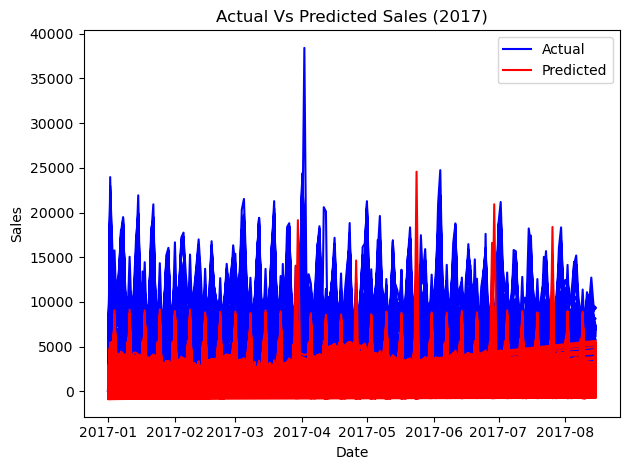

In [32]:
# plot the actual y and predicted y to compare
plt.figure(figure = (20, 20))
plt.plot(df_2017.index.get_level_values('date').to_timestamp(), df_2017["y"], label = "Actual", color = "blue")
plt.plot(df_2017.index.get_level_values('date').to_timestamp(), df_2017["x_pred"], label = "Predicted", color = "red")

plt.xlabel('Date')
plt.ylabel("Sales")
plt.title("Actual Vs Predicted Sales (2017)")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
lin_ptest = model1.predict(x_test)
lin_ptest

array([367.64508306, 341.08938391, 319.6412452 , ..., 137.75764525,
        87.27641722, 130.39337677])

In [34]:
lin_pred = pd.DataFrame(lin_ptest, index = x_test.index, columns =["sales"])
lin_pred

,,sales
date,id,
2017-08-16,3000888,367.645083
2017-08-17,3002670,341.089384
2017-08-18,3004452,319.641245
2017-08-19,3006234,493.250079
2017-08-20,3008016,518.720263
...,...,...
2017-08-27,3022271,292.306398
2017-08-28,3024053,186.264853
2017-08-29,3025835,137.757645


In [37]:
lin_sub = test_pd.merge(lin_pred, left_index = True, right_index = True, how = 'outer')
lin_sub

store_nbr                      family  onpromotion  \
date       id                                                           
2017-08-16 3000888         1                  AUTOMOTIVE            0   
           3000889         1                   BABY CARE            0   
           3000890         1                      BEAUTY            2   
           3000891         1                   BEVERAGES           20   
           3000892         1                       BOOKS            0   
...                      ...                         ...          ...   
2017-08-31 3029395         9                     POULTRY            1   
           3029396         9              PREPARED FOODS            0   
           3029397         9                     PRODUCE            1   
           3029398         9  SCHOOL AND OFFICE SUPPLIES            9   
           3029399         9                     SEAFOOD            0   

                          sales  
date       id                    
2017-08-16 3000888   367.645083  
           3000889   -42.956952  
           3000890    96.048217  
           3000891  1271.338505  
           3000892   658.795571  
...                         ...  
2017-08-31 3029395   699.615296  
           3029396   254.851983  
           3029397   359.695875  
           3029398   367.162259  
           3029399   130.393377  

[28512 rows x 4 columns]

In [38]:
lin_sub = lin_sub.reset_index().set_index(['store_nbr', 'family', 'date']).drop("onpromotion", axis = 1)
lin_sub

id        sales
store_nbr family                     date                            
1         AUTOMOTIVE                 2017-08-16  3000888   367.645083
          BABY CARE                  2017-08-16  3000889   -42.956952
          BEAUTY                     2017-08-16  3000890    96.048217
          BEVERAGES                  2017-08-16  3000891  1271.338505
          BOOKS                      2017-08-16  3000892   658.795571
...                                                  ...          ...
9         POULTRY                    2017-08-31  3029395   699.615296
          PREPARED FOODS             2017-08-31  3029396   254.851983
          PRODUCE                    2017-08-31  3029397   359.695875
          SCHOOL AND OFFICE SUPPLIES 2017-08-31  3029398   367.162259
          SEAFOOD                    2017-08-31  3029399   130.393377

[28512 rows x 2 columns]

In [39]:
lin_sub.to_csv("lin_sub.csv", index = False)

> Based on how poor the resulsts are we will be using log values of sales to train our model as there are of zero values in our target set

In [26]:
# Instantiate Linear Regression model with fit intercept equals true
model = LinearRegression().fit(x, np.log1p(y))

In [34]:
scoring(y = np.log1p(y), y_pred = model.predict(x))

MAE: 1.86974, RMSE: 2.22477, R^2:0.31887


In [28]:
lint_pred = model.predict(x_test)
lint_pred

array([3.34042093, 3.31061601, 3.28042434, ..., 2.14177944, 2.06139814,
       2.14464825])

In [29]:
lint_sub = test_pd.merge(pd.DataFrame(np.expm1(lint_pred), index = x_test.index, columns =["sales"]), left_index = True, right_index = True, how = 'outer')
lint_sub

store_nbr                      family  onpromotion  \
date       id                                                           
2017-08-16 3000888         1                  AUTOMOTIVE            0   
           3000889         1                   BABY CARE            0   
           3000890         1                      BEAUTY            2   
           3000891         1                   BEVERAGES           20   
           3000892         1                       BOOKS            0   
...                      ...                         ...          ...   
2017-08-31 3029395         9                     POULTRY            1   
           3029396         9              PREPARED FOODS            0   
           3029397         9                     PRODUCE            1   
           3029398         9  SCHOOL AND OFFICE SUPPLIES            9   
           3029399         9                     SEAFOOD            0   

                        sales  
date       id                  
2017-08-16 3000888  27.231007  
           3000889  16.090653  
           3000890  17.314222  
           3000891  96.032859  
           3000892  32.909321  
...                       ...  
2017-08-31 3029395  95.978791  
           3029396  54.794260  
           3029397  55.819813  
           3029398  12.953844  
           3029399   7.539037  

[28512 rows x 4 columns]

In [31]:
lint_sub = lint_sub.reset_index().set_index(['store_nbr', 'family', 'date']).drop("onpromotion", axis = 1)
lint_sub

id      sales
store_nbr family                     date                          
1         AUTOMOTIVE                 2017-08-16  3000888  27.231007
          BABY CARE                  2017-08-16  3000889  16.090653
          BEAUTY                     2017-08-16  3000890  17.314222
          BEVERAGES                  2017-08-16  3000891  96.032859
          BOOKS                      2017-08-16  3000892  32.909321
...                                                  ...        ...
9         POULTRY                    2017-08-31  3029395  95.978791
          PREPARED FOODS             2017-08-31  3029396  54.794260
          PRODUCE                    2017-08-31  3029397  55.819813
          SCHOOL AND OFFICE SUPPLIES 2017-08-31  3029398  12.953844
          SEAFOOD                    2017-08-31  3029399   7.539037

[28512 rows x 2 columns]

In [32]:
lint_sub.to_csv('Linear_sub.csv', index = False)

In [35]:
# Instantiate Linear Regression model with fit intercept equals False
modle = LinearRegression(fit_intercept = False).fit(x, np.log1p(y))

In [38]:
scoring(y = np.log1p(y), y_pred = modle.predict(x))

MAE: 1.86974, RMSE: 2.22477, R^2:0.31887


### MODELLING WITH XGBOOST

We will model with Xgboost but will curate a different dataframe for our XGboost model, one that does not consume as much memory as that for LinearRegression

In [39]:
# Extract numerical features from our date columns
tree = train_df.copy().reset_index()
tree["date"] = tree["date"].dt.to_timestamp()          # Convert Period to Timestamp

# For test set
tree["day"] = tree.date.dt.day
tree["month"] = tree.date.dt.month
tree["year"] = tree.date.dt.year
tree["dayofweek"] = tree.date.dt.dayofweek

# Label encode family, city, state, type
tree["family"] = tree["family"].cat.codes
tree["state"] = tree["state"].cat.codes
tree["city"] = tree["city"].cat.codes
tree["type"] = tree["type"].cat.codes
tree['store_nbr'] = tree['store_nbr'].cat.codes
tree['cluster'] = tree['cluster'].cat.codes

tree = tree.set_index("id").drop('date', axis = 1)

tree

,store_nbr,family,city,state,type,cluster,const,trend,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,sales,day,month,year,dayofweek
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,18,12,3,4,1.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,93.14,94.88,1,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.0,0.000000,1,1,2013,1
1782,0,0,18,12,3,4,1.0,2.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630,0.085965,0.996298,0.069756,0.997564,0.139173,0.990268,93.14,93.14,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.0,2.000000,2,1,2013,2
3564,0,0,18,12,3,4,1.0,3.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532,0.171293,0.985220,0.139173,0.990268,0.275637,0.961262,92.97,93.14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,3.000000,3,1,2013,3
5346,0,0,18,12,3,4,1.0,4.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740,0.255353,0.966848,0.207912,0.978148,0.406737,0.913545,93.12,92.97,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,3.000000,4,1,2013,4
7128,0,0,18,12,3,4,1.0,5.0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309,0.337523,0.941317,0.275637,0.961262,0.529919,0.848048,93.15,93.12,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,5.000000,5,1,2013,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993759,53,32,18,12,1,13,1.0,1684.0,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.628763,-0.777597,0.977848,0.209315,-0.891981,0.452072,0.409356,-0.912375,0.255353,0.966848,0.334880,-0.942261,-0.631088,0.775711,48.81,48.54,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,23.830999,11,8,2017,4
2995541,53,32,18,12,1,13,1.0,1685.0,4,0.0,0.0,0.0,1.0,0.0,0.0,-0.642055,-0.766659,0.984474,0.175531,-0.867456,0.497513,0.345612,-0.938377,0.337523,0.941317,0.269797,-0.962917,-0.519584,0.854419,48.40,48.81,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,16.859001,12,8,2017,5
2997323,53,32,18,12,1,13,1.0,1686.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.655156,-0.755493,0.989932,0.141540,-0.840618,0.541628,0.280231,-0.959933,0.417194,0.908818,0.203456,-0.979084,-0.398401,0.917211,48.00,48.40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,20.000000,13,8,2017,6


In [40]:
tree.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3008016 entries, 0 to 3000887
Data columns (total 68 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   store_nbr                int8   
 1   family                   int8   
 2   city                     int8   
 3   state                    int8   
 4   type                     int8   
 5   cluster                  int8   
 6   const                    float64
 7   trend                    float64
 8   onpromotion              uint32 
 9   s(2,7)                   float64
 10  s(3,7)                   float64
 11  s(4,7)                   float64
 12  s(5,7)                   float64
 13  s(6,7)                   float64
 14  s(7,7)                   float64
 15  sin(1,freq=YE-DEC)       float64
 16  cos(1,freq=YE-DEC)       float64
 17  sin(2,freq=YE-DEC)       float64
 18  cos(2,freq=YE-DEC)       float64
 19  sin(3,freq=YE-DEC)       float64
 20  cos(3,freq=YE-DEC)       float64
 21  sin(4,freq=YE

In [41]:
# Extract numerical features from our date columns
test_tree = test_df.copy().reset_index()
test_tree["date"] = test_tree["date"].dt.to_timestamp()          # Convert Period to Timestamp

# For test set
test_tree["day"] =  test_tree.date.dt.day
test_tree["month"] = test_tree.date.dt.month
test_tree["year"] = test_tree.date.dt.year
test_tree["dayofweek"] = test_tree.date.dt.dayofweek


# Label encode family, city, state, type
test_tree["family"] = test_tree["family"].cat.codes
test_tree["state"] = test_tree["state"].cat.codes
test_tree["city"] = test_tree["city"].cat.codes
test_tree["type"] = test_tree["type"].cat.codes
test_tree['store_nbr'] = test_tree['store_nbr'].cat.codes
test_tree['cluster'] = test_tree['cluster'].cat.codes

test_tree = test_tree.set_index("id").drop("date", axis = 1)

test_tree

,store_nbr,family,city,state,type,cluster,const,trend,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,day,month,year,dayofweek
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3000888,0,0,18,12,3,4,1.0,1689.0,0,1.0,0.0,0.0,0.0,0.0,0.0,-0.693281,-0.720667,0.999250,0.038722,-0.746972,0.664855,0.077386,-0.997001,0.635432,0.772157,1.224647e-16,-1.000000,-2.449294e-16,1.000000,46.80,47.57,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,16,8,2017,2
3002670,0,0,18,12,3,4,1.0,1690.0,0,0.0,1.0,0.0,0.0,0.0,0.0,-0.705584,-0.708627,0.999991,0.004304,-0.711657,0.702527,0.008607,-0.999963,0.699458,0.714673,-6.824241e-02,-0.997669,1.361666e-01,0.990686,47.07,46.80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,17,8,2017,3
3004452,0,0,18,12,3,4,1.0,1691.0,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.717677,-0.696376,0.999546,-0.030120,-0.674444,0.738326,-0.060213,-0.998186,0.758306,0.651899,-1.361666e-01,-0.990686,2.697968e-01,0.962917,48.59,47.07,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,18,8,2017,4
3006234,0,0,18,12,3,4,1.0,1692.0,0,0.0,0.0,0.0,1.0,0.0,0.0,-0.729558,-0.683919,0.997917,-0.064508,-0.635432,0.772157,-0.128748,-0.991677,0.811539,0.584298,-2.034560e-01,-0.979084,3.984011e-01,0.917211,48.19,48.59,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,19,8,2017,5
3008016,0,0,18,12,3,4,1.0,1693.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.741222,-0.671260,0.995105,-0.098820,-0.594727,0.803928,-0.196673,-0.980469,0.858764,0.512371,-2.697968e-01,-0.962917,5.195840e-01,0.854419,47.79,48.19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,20,8,2017,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022271,53,32,18,12,1,13,1.0,1700.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.816538,-0.577292,0.942761,-0.333469,-0.271958,0.962309,-0.628763,-0.777597,0.997917,-0.064508,-6.825531e-01,-0.730836,9.976688e-01,0.068242,46.82,47.23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,27,8,2017,6
3024053,53,32,18,12,1,13,1.0,1701.0,0,0.0,0.0,0.0,0.0,0.0,1.0,-0.826354,-0.563151,0.930724,-0.365723,-0.221922,0.975065,-0.680773,-0.732494,0.988678,-0.150055,-7.308360e-01,-0.682553,9.976688e-01,-0.068242,46.40,46.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,28,8,2017,0
3025835,53,32,18,12,1,13,1.0,1702.0,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.835925,-0.548843,0.917584,-0.397543,-0.171293,0.985220,-0.729558,-0.683919,0.972118,-0.234491,-7.757113e-01,-0.631088,9.790841e-01,-0.203456,46.46,46.40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,29,8,2017,1


In [15]:
test_tree.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28512 entries, 3000888 to 3029399
Data columns (total 67 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   store_nbr                28512 non-null  int8   
 1   family                   28512 non-null  int8   
 2   city                     28512 non-null  int8   
 3   state                    28512 non-null  int8   
 4   type                     28512 non-null  int8   
 5   cluster                  28512 non-null  int8   
 6   const                    28512 non-null  float64
 7   trend                    28512 non-null  float64
 8   onpromotion              28512 non-null  uint32 
 9   s(2,7)                   28512 non-null  float64
 10  s(3,7)                   28512 non-null  float64
 11  s(4,7)                   28512 non-null  float64
 12  s(5,7)                   28512 non-null  float64
 13  s(6,7)                   28512 non-null  float64
 14  s(7,7)             

In [30]:
train_df

city      state type cluster  const   trend  \
store_nbr family     date                                                       
1         AUTOMOTIVE 2013-01-01  Quito  Pichincha    D      13    1.0     1.0   
                     2013-01-02  Quito  Pichincha    D      13    1.0     2.0   
                     2013-01-03  Quito  Pichincha    D      13    1.0     3.0   
                     2013-01-04  Quito  Pichincha    D      13    1.0     4.0   
                     2013-01-05  Quito  Pichincha    D      13    1.0     5.0   
...                                ...        ...  ...     ...    ...     ...   
9         SEAFOOD    2017-08-11  Quito  Pichincha    B       6    1.0  1684.0   
                     2017-08-12  Quito  Pichincha    B       6    1.0  1685.0   
                     2017-08-13  Quito  Pichincha    B       6    1.0  1686.0   
                     2017-08-14  Quito  Pichincha    B       6    1.0  1687.0   
                     2017-08-15  Quito  Pichincha    B       6    1.0  1688.0   

                                      id  onpromotion  s(2,7)  s(3,7)  s(4,7)  \
store_nbr family     date                                                       
1         AUTOMOTIVE 2013-01-01        0            0     0.0     0.0     0.0   
                     2013-01-02     1782            0     1.0     0.0     0.0   
                     2013-01-03     3564            0     0.0     1.0     0.0   
                     2013-01-04     5346            0     0.0     0.0     1.0   
                     2013-01-05     7128            0     0.0     0.0     0.0   
...                                  ...          ...     ...     ...     ...   
9         SEAFOOD    2017-08-11  2993759            0     0.0     0.0     1.0   
                     2017-08-12  2995541            4     0.0     0.0     0.0   
                     2017-08-13  2997323            0     0.0     0.0     0.0   
                     2017-08-14  2999105            0     0.0     0.0     0.0   
                     2017-08-15  3000887            0     0.0     0.0     0.0   

                                 s(5,7)  s(6,7)  s(7,7)  sin(1,freq=YE-DEC)  \
store_nbr family     date                                                     
1         AUTOMOTIVE 2013-01-01     0.0     0.0     0.0            0.000000   
                     2013-01-02     0.0     0.0     0.0            0.017213   
                     2013-01-03     0.0     0.0     0.0            0.034422   
                     2013-01-04     0.0     0.0     0.0            0.051620   
                     2013-01-05     1.0     0.0     0.0            0.068802   
...                                 ...     ...     ...                 ...   
9         SEAFOOD    2017-08-11     0.0     0.0     0.0           -0.628763   
                     2017-08-12     1.0     0.0     0.0           -0.642055   
                     2017-08-13     0.0     1.0     0.0           -0.655156   
                     2017-08-14     0.0     0.0     1.0           -0.668064   
                     2017-08-15     0.0     0.0     0.0           -0.680773   

                                 cos(1,freq=YE-DEC)  sin(2,freq=YE-DEC)  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2013-01-01            1.000000            0.000000   
                     2013-01-02            0.999852            0.034422   
                     2013-01-03            0.999407            0.068802   
                     2013-01-04            0.998667            0.103102   
                     2013-01-05            0.997630            0.137279   
...                                             ...                 ...   
9         SEAFOOD    2017-08-11           -0.777597            0.977848   
                     2017-08-12           -0.766659            0.984474   
                     2017-08-13           -0.755493            0.989932   
                     2017-08-14           -0.744104            0.994218  

In [14]:
# Extract numerical features from our date columns
reet = train_df.copy().reset_index()
reet["date"] = reet["date"].dt.to_timestamp()          # Convert Period to Timestamp

# For test set
reet["day"] = reet.date.dt.day
reet["month"] = reet.date.dt.month
reet["year"] = reet.date.dt.year
reet["dayofweek"] = reet.date.dt.dayofweek

# freq_encode family, city, state, type
reet["family"] = reet["family"].cat.codes
reet["store_nbr"] = reet["store_nbr"].cat.codes

# Create a train and validation set so as to get the optimal XGBOOST model
split_index = int(2309471)

cat_col = ['city', 'type', 'state', 'cluster']

for col in cat_col:
    freq = reet[col].value_counts(normalize = True)
    reet[col + '_freq'] = reet[col].map(freq)
    reet = reet.drop(col, axis = 1)

train_reet = reet.iloc[:split_index]
val_reet = reet.iloc[split_index:]

train_reet = train_reet.set_index("id").drop('date', axis = 1)
val_reet = val_reet.set_index("id").drop('date', axis = 1)

val_reet

,store_nbr,family,const,trend,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,sales,day,month,year,dayofweek,city_freq,type_freq,state_freq,cluster_freq
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
512802,41,15,1.0,288.0,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.974100,0.226116,-0.440519,-0.897743,0.774884,-0.632103,0.790946,0.611886,-0.417194,0.908818,0.816970,0.576680,0.942261,-0.334880,101.15,102.46,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0.0,0.000000,15,10,2013,1,0.333333,0.166667,0.351852,0.074074
514584,41,15,1.0,289.0,0,1.0,0.0,0.0,0.0,0.0,0.0,-0.970064,0.242850,-0.471160,-0.882048,0.741222,-0.671260,0.831171,0.556017,-0.337523,0.941317,0.854419,0.519584,0.887885,-0.460065,102.34,101.15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,0.000000,16,10,2013,2,0.333333,0.166667,0.351852,0.074074
516366,41,15,1.0,290.0,0,0.0,1.0,0.0,0.0,0.0,0.0,-0.965740,0.259512,-0.501242,-0.865307,0.705584,-0.708627,0.867456,0.497513,-0.255353,0.966848,0.887885,0.460065,0.816970,-0.576680,100.72,102.34,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.000000,17,10,2013,3,0.333333,0.166667,0.351852,0.074074
518148,41,15,1.0,291.0,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.961130,0.276097,-0.530730,-0.847541,0.668064,-0.744104,0.899631,0.436651,-0.171293,0.985220,0.917211,0.398401,0.730836,-0.682553,100.87,100.72,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.000000,18,10,2013,4,0.333333,0.166667,0.351852,0.074074
519930,41,15,1.0,292.0,0,0.0,0.0,0.0,1.0,0.0,0.0,-0.956235,0.292600,-0.559589,-0.828770,0.628763,-0.777597,0.927542,0.373720,-0.085965,0.996298,0.942261,0.334880,0.631088,-0.775711,100.34,100.87,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.000000,19,10,2013,5,0.333333,0.166667,0.351852,0.074074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993759,53,32,1.0,1684.0,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.628763,-0.777597,0.977848,0.209315,-0.891981,0.452072,0.409356,-0.912375,0.255353,0.966848,0.334880,-0.942261,-0.631088,0.775711,48.81,48.54,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,23.830999,11,8,2017,4,0.333333,0.148148,0.351852,0.111111
2995541,53,32,1.0,1685.0,4,0.0,0.0,0.0,1.0,0.0,0.0,-0.642055,-0.766659,0.984474,0.175531,-0.867456,0.497513,0.345612,-0.938377,0.337523,0.941317,0.269797,-0.962917,-0.519584,0.854419,48.40,48.81,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,16.859001,12,8,2017,5,0.333333,0.148148,0.351852,0.111111
2997323,53,32,1.0,1686.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.655156,-0.755493,0.989932,0.141540,-0.840618,0.541628,0.280231,-0.959933,0.417194,0.908818,0.203456,-0.979084,-0.398401,0.917211,48.00,48.40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,20.000000,13,8,2017,6,0.333333,0.148148,0.351852,0.111111


In [37]:
train_reet.type_freq.value_counts()

type_freq
0.277778    779856
0.333333    724152
0.148148    389928
0.074074    222816
0.166667    192719
Name: count, dtype: int64

In [42]:
train_reet.type_freq = train_reet.type_freq.astype(float)
train_reet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2309471 entries, 0 to 511020
Data columns (total 68 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   store_nbr                int8   
 1   family                   int8   
 2   const                    float64
 3   trend                    float64
 4   onpromotion              uint32 
 5   s(2,7)                   float64
 6   s(3,7)                   float64
 7   s(4,7)                   float64
 8   s(5,7)                   float64
 9   s(6,7)                   float64
 10  s(7,7)                   float64
 11  sin(1,freq=YE-DEC)       float64
 12  cos(1,freq=YE-DEC)       float64
 13  sin(2,freq=YE-DEC)       float64
 14  cos(2,freq=YE-DEC)       float64
 15  sin(3,freq=YE-DEC)       float64
 16  cos(3,freq=YE-DEC)       float64
 17  sin(4,freq=YE-DEC)       float64
 18  cos(4,freq=YE-DEC)       float64
 19  sin(5,freq=YE-DEC)       float64
 20  cos(5,freq=YE-DEC)       float64
 21  sin(1,freq=QE-

In [43]:
val_reet.type_freq = val_reet.type_freq.astype(float)
val_reet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 698545 entries, 512802 to 3000887
Data columns (total 68 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   store_nbr                698545 non-null  int8   
 1   family                   698545 non-null  int8   
 2   const                    698545 non-null  float64
 3   trend                    698545 non-null  float64
 4   onpromotion              698545 non-null  uint32 
 5   s(2,7)                   698545 non-null  float64
 6   s(3,7)                   698545 non-null  float64
 7   s(4,7)                   698545 non-null  float64
 8   s(5,7)                   698545 non-null  float64
 9   s(6,7)                   698545 non-null  float64
 10  s(7,7)                   698545 non-null  float64
 11  sin(1,freq=YE-DEC)       698545 non-null  float64
 12  cos(1,freq=YE-DEC)       698545 non-null  float64
 13  sin(2,freq=YE-DEC)       698545 non-null  float64
 14  cos

In [26]:
val_reet.family.value_counts()

family
31    21944
24    21944
30    21944
29    21944
28    21944
27    21944
26    21944
25    21944
23    21944
32    21944
22    21944
21    21944
20    21944
19    21944
18    21944
17    21944
16    21944
15    21657
0     20256
1     20256
2     20256
3     20256
4     20256
5     20256
6     20256
7     20256
8     20256
9     20256
10    20256
11    20256
12    20256
13    20256
14    20256
Name: count, dtype: int64

In [36]:
val_reet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 698545 entries, 512802 to 3000887
Data columns (total 68 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   store_nbr                698545 non-null  int8    
 1   family                   698545 non-null  int8    
 2   const                    698545 non-null  float64 
 3   trend                    698545 non-null  float64 
 4   onpromotion              698545 non-null  uint32  
 5   s(2,7)                   698545 non-null  float64 
 6   s(3,7)                   698545 non-null  float64 
 7   s(4,7)                   698545 non-null  float64 
 8   s(5,7)                   698545 non-null  float64 
 9   s(6,7)                   698545 non-null  float64 
 10  s(7,7)                   698545 non-null  float64 
 11  sin(1,freq=YE-DEC)       698545 non-null  float64 
 12  cos(1,freq=YE-DEC)       698545 non-null  float64 
 13  sin(2,freq=YE-DEC)       698545 non-null  f

In [19]:
# Instantiation 
xgb_r = xg.XGBRegressor(seed = 42,
                        verbosity = 0 ,
                        n_estimators = 1500,
                        learning_rate = 0.05,
                        objective = 'reg:squarederror',
                        gamma = 0.3,
                        early_stopping_rounds=40 ) # Early stopping applied for each fold
xgb_r

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=40,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.3, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [17]:
# Create a train and validation set so as to get the optimal XGBOOST model
split_index = int(0.8 * len(tree))

train_tree = tree.iloc[:split_index]
val_tree = tree.iloc[split_index:]

In [20]:
xgb_r.fit(
    train_tree.drop("sales", axis = 1), np.log1p(train_tree.sales),
    eval_set = [(val_tree.drop("sales", axis = 1), np.log1p(val_tree.sales))]
)

[0]	validation_0-rmse:2.67692
[1]	validation_0-rmse:2.60070
[2]	validation_0-rmse:2.52928
[3]	validation_0-rmse:2.46095
[4]	validation_0-rmse:2.40040
[5]	validation_0-rmse:2.34914
[6]	validation_0-rmse:2.29271
[7]	validation_0-rmse:2.24732
[8]	validation_0-rmse:2.20122
[9]	validation_0-rmse:2.15906
[10]	validation_0-rmse:2.11444
[11]	validation_0-rmse:2.07227
[12]	validation_0-rmse:2.04177
[13]	validation_0-rmse:2.01459
[14]	validation_0-rmse:1.98668
[15]	validation_0-rmse:1.96010
[16]	validation_0-rmse:1.93652
[17]	validation_0-rmse:1.91321
[18]	validation_0-rmse:1.89469
[19]	validation_0-rmse:1.87719
[20]	validation_0-rmse:1.85945
[21]	validation_0-rmse:1.83737
[22]	validation_0-rmse:1.82762
[23]	validation_0-rmse:1.81947
[24]	validation_0-rmse:1.80976
[25]	validation_0-rmse:1.79741
[26]	validation_0-rmse:1.79015
[27]	validation_0-rmse:1.77825
[28]	validation_0-rmse:1.77291
[29]	validation_0-rmse:1.76494
[30]	validation_0-rmse:1.75807
[31]	validation_0-rmse:1.74829
[32]	validation_0-

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=40,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.3, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [27]:
# Instantiation 
xgb_r2 = xg.XGBRegressor(seed = 42,
                        verbosity = 0 ,
                        n_estimators = 1500,
                        learning_rate = 0.09,
                        objective = 'reg:squarederror',
                        gamma = 0.5,
                        early_stopping_rounds=70 ) # Early stopping applied for each fold
xgb_r2

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=70,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.5, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.09, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [44]:
xgb_r2.fit(
    train_reet.drop("sales", axis = 1), np.log1p(train_reet.sales),
    eval_set = [(val_reet.drop("sales", axis = 1), np.log1p(val_reet.sales))]
)

[0]	validation_0-rmse:2.62969
[1]	validation_0-rmse:2.48770
[2]	validation_0-rmse:2.37381
[3]	validation_0-rmse:2.27739
[4]	validation_0-rmse:2.19427
[5]	validation_0-rmse:2.11355
[6]	validation_0-rmse:2.04825
[7]	validation_0-rmse:1.99213
[8]	validation_0-rmse:1.92638
[9]	validation_0-rmse:1.88665
[10]	validation_0-rmse:1.85928
[11]	validation_0-rmse:1.82495
[12]	validation_0-rmse:1.79351
[13]	validation_0-rmse:1.76439
[14]	validation_0-rmse:1.73122
[15]	validation_0-rmse:1.71586
[16]	validation_0-rmse:1.70586
[17]	validation_0-rmse:1.68127
[18]	validation_0-rmse:1.67244
[19]	validation_0-rmse:1.65613
[20]	validation_0-rmse:1.64720
[21]	validation_0-rmse:1.63918
[22]	validation_0-rmse:1.62373
[23]	validation_0-rmse:1.61796
[24]	validation_0-rmse:1.61331
[25]	validation_0-rmse:1.60233
[26]	validation_0-rmse:1.59905
[27]	validation_0-rmse:1.59018
[28]	validation_0-rmse:1.58139
[29]	validation_0-rmse:1.57589
[30]	validation_0-rmse:1.56754
[31]	validation_0-rmse:1.56190
[32]	validation_0-

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=70,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.5, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.09, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [22]:
(val_tree.sales.mean(), len(val_tree))

(404.90588, 601604)

In [42]:
# Extract numerical features from our date columns
treet = train_df.copy().reset_index()
treet["date"] = treet["date"].dt.to_timestamp()          # Convert Period to Timestamp

# For train set
treet["day"] = treet.date.dt.day
treet["month"] = treet.date.dt.month
treet["year"] = treet.date.dt.year
treet["dayofweek"] = treet.date.dt.dayofweek

# freq_encode family and store_nbr
treet["family"] = treet["family"].cat.codes
treet["store_nbr"] = treet["store_nbr"].cat.codes

treet = treet.set_index("id").drop('date', axis = 1)

In [43]:
# Extract numerical features from our date columns
tree_test = test_df.copy().reset_index()
tree_test["date"] = tree_test["date"].dt.to_timestamp()          # Convert Period to Timestamp

# For test set
tree_test["day"] = tree_test.date.dt.day
tree_test["month"] = tree_test.date.dt.month
tree_test["year"] = tree_test.date.dt.year
tree_test["dayofweek"] = tree_test.date.dt.dayofweek

# freq_encode family and store_nbr
tree_test["family"] = tree_test["family"].cat.codes
tree_test["store_nbr"] = tree_test["store_nbr"].cat.codes


tree_test = tree_test.set_index("id").drop('date', axis = 1)

In [44]:
# Use frequency encoding for the remaining categorical columns
cat_col = ['city', 'type', 'state', 'cluster']

for col in cat_col:
    freq = treet[col].value_counts(normalize = True)
    treet[col + '_freq'] = treet[col].map(freq)
    tree_test[col + '_freq'] = tree_test[col].map(freq)
    treet = treet.drop(col, axis = 1)
    tree_test = tree_test.drop(col, axis = 1)

tree_test

,store_nbr,family,const,trend,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,day,month,year,dayofweek,city_freq,type_freq,state_freq,cluster_freq
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3000888,0,0,1.0,1689.0,0,1.0,0.0,0.0,0.0,0.0,0.0,-0.693281,-0.720667,0.999250,0.038722,-0.746972,0.664855,0.077386,-0.997001,0.635432,0.772157,1.224647e-16,-1.000000,-2.449294e-16,1.000000,46.80,47.57,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,16,8,2017,2,0.333333,0.333333,0.351852,0.074074
3002670,0,0,1.0,1690.0,0,0.0,1.0,0.0,0.0,0.0,0.0,-0.705584,-0.708627,0.999991,0.004304,-0.711657,0.702527,0.008607,-0.999963,0.699458,0.714673,-6.824241e-02,-0.997669,1.361666e-01,0.990686,47.07,46.80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,17,8,2017,3,0.333333,0.333333,0.351852,0.074074
3004452,0,0,1.0,1691.0,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.717677,-0.696376,0.999546,-0.030120,-0.674444,0.738326,-0.060213,-0.998186,0.758306,0.651899,-1.361666e-01,-0.990686,2.697968e-01,0.962917,48.59,47.07,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,18,8,2017,4,0.333333,0.333333,0.351852,0.074074
3006234,0,0,1.0,1692.0,0,0.0,0.0,0.0,1.0,0.0,0.0,-0.729558,-0.683919,0.997917,-0.064508,-0.635432,0.772157,-0.128748,-0.991677,0.811539,0.584298,-2.034560e-01,-0.979084,3.984011e-01,0.917211,48.19,48.59,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,19,8,2017,5,0.333333,0.333333,0.351852,0.074074
3008016,0,0,1.0,1693.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.741222,-0.671260,0.995105,-0.098820,-0.594727,0.803928,-0.196673,-0.980469,0.858764,0.512371,-2.697968e-01,-0.962917,5.195840e-01,0.854419,47.79,48.19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,20,8,2017,6,0.333333,0.333333,0.351852,0.074074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022271,53,32,1.0,1700.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.816538,-0.577292,0.942761,-0.333469,-0.271958,0.962309,-0.628763,-0.777597,0.997917,-0.064508,-6.825531e-01,-0.730836,9.976688e-01,0.068242,46.82,47.23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,27,8,2017,6,0.333333,0.148148,0.351852,0.111111
3024053,53,32,1.0,1701.0,0,0.0,0.0,0.0,0.0,0.0,1.0,-0.826354,-0.563151,0.930724,-0.365723,-0.221922,0.975065,-0.680773,-0.732494,0.988678,-0.150055,-7.308360e-01,-0.682553,9.976688e-01,-0.068242,46.40,46.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,28,8,2017,0,0.333333,0.148148,0.351852,0.111111
3025835,53,32,1.0,1702.0,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.835925,-0.548843,0.917584,-0.397543,-0.171293,0.985220,-0.729558,-0.683919,0.972118,-0.234491,-7.757113e-01,-0.631088,9.790841e-01,-0.203456,46.46,46.40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,29,8,2017,1,0.333333,0.148148,0.351852,0.111111


In [45]:
tree_x = treet.drop('sales', axis = 1)
tree_x

,store_nbr,family,const,trend,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,day,month,year,dayofweek,city_freq,type_freq,state_freq,cluster_freq
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,1.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,93.14,94.88,1,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.0,1,1,2013,1,0.333333,0.333333,0.351852,0.074074
1782,0,0,1.0,2.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630,0.085965,0.996298,0.069756,0.997564,0.139173,0.990268,93.14,93.14,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.0,2,1,2013,2,0.333333,0.333333,0.351852,0.074074
3564,0,0,1.0,3.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532,0.171293,0.985220,0.139173,0.990268,0.275637,0.961262,92.97,93.14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,3,1,2013,3,0.333333,0.333333,0.351852,0.074074
5346,0,0,1.0,4.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740,0.255353,0.966848,0.207912,0.978148,0.406737,0.913545,93.12,92.97,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,4,1,2013,4,0.333333,0.333333,0.351852,0.074074
7128,0,0,1.0,5.0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309,0.337523,0.941317,0.275637,0.961262,0.529919,0.848048,93.15,93.12,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,5,1,2013,5,0.333333,0.333333,0.351852,0.074074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993759,53,32,1.0,1684.0,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.628763,-0.777597,0.977848,0.209315,-0.891981,0.452072,0.409356,-0.912375,0.255353,0.966848,0.334880,-0.942261,-0.631088,0.775711,48.81,48.54,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,11,8,2017,4,0.333333,0.148148,0.351852,0.111111
2995541,53,32,1.0,1685.0,4,0.0,0.0,0.0,1.0,0.0,0.0,-0.642055,-0.766659,0.984474,0.175531,-0.867456,0.497513,0.345612,-0.938377,0.337523,0.941317,0.269797,-0.962917,-0.519584,0.854419,48.40,48.81,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,12,8,2017,5,0.333333,0.148148,0.351852,0.111111
2997323,53,32,1.0,1686.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.655156,-0.755493,0.989932,0.141540,-0.840618,0.541628,0.280231,-0.959933,0.417194,0.908818,0.203456,-0.979084,-0.398401,0.917211,48.00,48.40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,13,8,2017,6,0.333333,0.148148,0.351852,0.111111


In [46]:
tree_y = np.log1p(treet.sales)
tree_y

id
0          0.000000
1782       1.098612
3564       1.386294
5346       1.386294
7128       1.791759
             ...   
2993759    3.212093
2995541    2.882508
2997323    3.044523
2999105    2.890372
3000887    2.833213
Name: sales, Length: 3008016, dtype: float32

In [52]:
# Instantiation 
model2 = xg.XGBRegressor(seed = 42,
                        verbosity = 0 ,
                        n_estimators = 304,
                        learning_rate = 0.09,
                        objective = 'reg:squarederror',
                        gamma = 0.5)
model2

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.5, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.09, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=304, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [55]:
tree_x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3008016 entries, 0 to 3000887
Data columns (total 67 columns):
 #   Column                   Dtype   
---  ------                   -----   
 0   store_nbr                int8    
 1   family                   int8    
 2   const                    float64 
 3   trend                    float64 
 4   onpromotion              uint32  
 5   s(2,7)                   float64 
 6   s(3,7)                   float64 
 7   s(4,7)                   float64 
 8   s(5,7)                   float64 
 9   s(6,7)                   float64 
 10  s(7,7)                   float64 
 11  sin(1,freq=YE-DEC)       float64 
 12  cos(1,freq=YE-DEC)       float64 
 13  sin(2,freq=YE-DEC)       float64 
 14  cos(2,freq=YE-DEC)       float64 
 15  sin(3,freq=YE-DEC)       float64 
 16  cos(3,freq=YE-DEC)       float64 
 17  sin(4,freq=YE-DEC)       float64 
 18  cos(4,freq=YE-DEC)       float64 
 19  sin(5,freq=YE-DEC)       float64 
 20  cos(5,freq=YE-DEC)       floa

In [47]:
tree_x.type_freq = tree_x.type_freq.astype(float)
tree_x

,store_nbr,family,const,trend,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,day,month,year,dayofweek,city_freq,type_freq,state_freq,cluster_freq
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,1.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,93.14,94.88,1,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.0,1,1,2013,1,0.333333,0.333333,0.351852,0.074074
1782,0,0,1.0,2.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630,0.085965,0.996298,0.069756,0.997564,0.139173,0.990268,93.14,93.14,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.0,2,1,2013,2,0.333333,0.333333,0.351852,0.074074
3564,0,0,1.0,3.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532,0.171293,0.985220,0.139173,0.990268,0.275637,0.961262,92.97,93.14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,3,1,2013,3,0.333333,0.333333,0.351852,0.074074
5346,0,0,1.0,4.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740,0.255353,0.966848,0.207912,0.978148,0.406737,0.913545,93.12,92.97,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,4,1,2013,4,0.333333,0.333333,0.351852,0.074074
7128,0,0,1.0,5.0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309,0.337523,0.941317,0.275637,0.961262,0.529919,0.848048,93.15,93.12,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,5,1,2013,5,0.333333,0.333333,0.351852,0.074074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993759,53,32,1.0,1684.0,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.628763,-0.777597,0.977848,0.209315,-0.891981,0.452072,0.409356,-0.912375,0.255353,0.966848,0.334880,-0.942261,-0.631088,0.775711,48.81,48.54,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,11,8,2017,4,0.333333,0.148148,0.351852,0.111111
2995541,53,32,1.0,1685.0,4,0.0,0.0,0.0,1.0,0.0,0.0,-0.642055,-0.766659,0.984474,0.175531,-0.867456,0.497513,0.345612,-0.938377,0.337523,0.941317,0.269797,-0.962917,-0.519584,0.854419,48.40,48.81,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,12,8,2017,5,0.333333,0.148148,0.351852,0.111111
2997323,53,32,1.0,1686.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.655156,-0.755493,0.989932,0.141540,-0.840618,0.541628,0.280231,-0.959933,0.417194,0.908818,0.203456,-0.979084,-0.398401,0.917211,48.00,48.40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,13,8,2017,6,0.333333,0.148148,0.351852,0.111111


In [48]:
tree_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28512 entries, 3000888 to 3029399
Data columns (total 67 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   store_nbr                28512 non-null  int8    
 1   family                   28512 non-null  int8    
 2   const                    28512 non-null  float64 
 3   trend                    28512 non-null  float64 
 4   onpromotion              28512 non-null  uint32  
 5   s(2,7)                   28512 non-null  float64 
 6   s(3,7)                   28512 non-null  float64 
 7   s(4,7)                   28512 non-null  float64 
 8   s(5,7)                   28512 non-null  float64 
 9   s(6,7)                   28512 non-null  float64 
 10  s(7,7)                   28512 non-null  float64 
 11  sin(1,freq=YE-DEC)       28512 non-null  float64 
 12  cos(1,freq=YE-DEC)       28512 non-null  float64 
 13  sin(2,freq=YE-DEC)       28512 non-null  float64 
 14  cos

In [50]:
tree_test.type_freq = tree_test.type_freq.astype(float)
tree_test

,store_nbr,family,const,trend,onpromotion,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(1,freq=QE-DEC)","cos(1,freq=QE-DEC)","sin(2,freq=QE-DEC)","cos(2,freq=QE-DEC)",dcoilwtico,dcoilwtico_lag,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_type_Additional,holiday_type_Bridge,holiday_type_Event,holiday_type_Holiday,holiday_type_Transfer,holiday_type_Work Day,holiday_transferred,is_holiday_lead,is_holiday,is_holiday_lag,is_christmas_lead(2),is_christmas_lead(1),is_christmas,is_christmas_lag(1),is_christmas_lag(2),is_christmas_lag(3),is_new_year_lead(3),is_new_year_lead(2),is_new_year_lead(1),is_new_year,is_new_year_lag(1),is_new_year_lag(2),is_payday_15,is_payday_end,is_payday_lead,is_payday,is_payday_lag,earthquake_impact,earthquake_decay,day,month,year,dayofweek,city_freq,type_freq,state_freq,cluster_freq
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3000888,0,0,1.0,1689.0,0,1.0,0.0,0.0,0.0,0.0,0.0,-0.693281,-0.720667,0.999250,0.038722,-0.746972,0.664855,0.077386,-0.997001,0.635432,0.772157,1.224647e-16,-1.000000,-2.449294e-16,1.000000,46.80,47.57,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,16,8,2017,2,0.333333,0.333333,0.351852,0.074074
3002670,0,0,1.0,1690.0,0,0.0,1.0,0.0,0.0,0.0,0.0,-0.705584,-0.708627,0.999991,0.004304,-0.711657,0.702527,0.008607,-0.999963,0.699458,0.714673,-6.824241e-02,-0.997669,1.361666e-01,0.990686,47.07,46.80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,17,8,2017,3,0.333333,0.333333,0.351852,0.074074
3004452,0,0,1.0,1691.0,0,0.0,0.0,1.0,0.0,0.0,0.0,-0.717677,-0.696376,0.999546,-0.030120,-0.674444,0.738326,-0.060213,-0.998186,0.758306,0.651899,-1.361666e-01,-0.990686,2.697968e-01,0.962917,48.59,47.07,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,18,8,2017,4,0.333333,0.333333,0.351852,0.074074
3006234,0,0,1.0,1692.0,0,0.0,0.0,0.0,1.0,0.0,0.0,-0.729558,-0.683919,0.997917,-0.064508,-0.635432,0.772157,-0.128748,-0.991677,0.811539,0.584298,-2.034560e-01,-0.979084,3.984011e-01,0.917211,48.19,48.59,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,19,8,2017,5,0.333333,0.333333,0.351852,0.074074
3008016,0,0,1.0,1693.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.741222,-0.671260,0.995105,-0.098820,-0.594727,0.803928,-0.196673,-0.980469,0.858764,0.512371,-2.697968e-01,-0.962917,5.195840e-01,0.854419,47.79,48.19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,20,8,2017,6,0.333333,0.333333,0.351852,0.074074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022271,53,32,1.0,1700.0,0,0.0,0.0,0.0,0.0,1.0,0.0,-0.816538,-0.577292,0.942761,-0.333469,-0.271958,0.962309,-0.628763,-0.777597,0.997917,-0.064508,-6.825531e-01,-0.730836,9.976688e-01,0.068242,46.82,47.23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,27,8,2017,6,0.333333,0.148148,0.351852,0.111111
3024053,53,32,1.0,1701.0,0,0.0,0.0,0.0,0.0,0.0,1.0,-0.826354,-0.563151,0.930724,-0.365723,-0.221922,0.975065,-0.680773,-0.732494,0.988678,-0.150055,-7.308360e-01,-0.682553,9.976688e-01,-0.068242,46.40,46.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,28,8,2017,0,0.333333,0.148148,0.351852,0.111111
3025835,53,32,1.0,1702.0,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.835925,-0.548843,0.917584,-0.397543,-0.171293,0.985220,-0.729558,-0.683919,0.972118,-0.234491,-7.757113e-01,-0.631088,9.790841e-01,-0.203456,46.46,46.40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,29,8,2017,1,0.333333,0.148148,0.351852,0.111111


In [58]:
print(tree_x.isna().sum()>1)

store_nbr       False
family          False
const           False
trend           False
onpromotion     False
                ...  
dayofweek       False
city_freq       False
type_freq       False
state_freq      False
cluster_freq    False
Length: 67, dtype: bool


In [59]:
model2.fit(tree_x, tree_y)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.5, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.09, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=304, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [66]:
tree_y_pred = model2.predict(tree_x)
tree_y_pred

array([-0.40285963,  1.2381908 ,  1.1700389 , ...,  2.841348  ,
        2.511703  ,  2.5012815 ], dtype=float32)

In [67]:
scoring(y = np.expm1(tree_y), y_pred =np.expm1(tree_y_pred) )

MAE: 100.54804, RMSE: 415.52773, R^2:0.85752


In [68]:
tree_test_pred = model2.predict(tree_test)
tree_test_pred

array([1.4401865, 1.4086591, 1.4408945, ..., 2.1646101, 2.1537924,
       2.1640625], dtype=float32)

In [69]:
xg_pred = pd.DataFrame(tree_test_pred, index = tree_test.index, columns =["sales"])
xg_pred

,sales
id,
3000888,1.440187
3002670,1.408659
3004452,1.440894
3006234,1.588065
3008016,1.058868
...,...
3022271,2.484452
3024053,2.199926
3025835,2.164610


In [72]:
xg_s = test_pd.reset_index().merge(xg_pred.reset_index(), on = 'id', how = 'outer')
xg_s

,date,id,store_nbr,family,onpromotion,sales
0,2017-08-16,3000888,1,AUTOMOTIVE,0,1.440187
1,2017-08-16,3000889,1,BABY CARE,0,0.085059
2,2017-08-16,3000890,1,BEAUTY,2,1.771355
3,2017-08-16,3000891,1,BEVERAGES,20,7.721927
4,2017-08-16,3000892,1,BOOKS,0,0.140917
...,...,...,...,...,...,...
28507,2017-08-31,3029395,9,POULTRY,1,5.350159
28508,2017-08-31,3029396,9,PREPARED FOODS,0,4.352091
28509,2017-08-31,3029397,9,PRODUCE,1,6.778551
28510,2017-08-31,3029398,9,SCHOOL AND OFFICE SUPPLIES,9,3.434449


In [73]:
xg_sub = xg_s.copy()
xg_sub['sales'] = np.expm1(xg_sub['sales'])
xg_sub

,date,id,store_nbr,family,onpromotion,sales
0,2017-08-16,3000888,1,AUTOMOTIVE,0,3.221483
1,2017-08-16,3000889,1,BABY CARE,0,0.088781
2,2017-08-16,3000890,1,BEAUTY,2,4.878816
3,2017-08-16,3000891,1,BEVERAGES,20,2256.304443
4,2017-08-16,3000892,1,BOOKS,0,0.151329
...,...,...,...,...,...,...
28507,2017-08-31,3029395,9,POULTRY,1,209.641724
28508,2017-08-31,3029396,9,PREPARED FOODS,0,76.640663
28509,2017-08-31,3029397,9,PRODUCE,1,877.794128
28510,2017-08-31,3029398,9,SCHOOL AND OFFICE SUPPLIES,9,30.014324


In [74]:
xg_sub = xg_sub.set_index(['store_nbr', 'family', 'date']).drop('onpromotion', axis = 1)
xg_sub

id        sales
store_nbr family                     date                            
1         AUTOMOTIVE                 2017-08-16  3000888     3.221483
          BABY CARE                  2017-08-16  3000889     0.088781
          BEAUTY                     2017-08-16  3000890     4.878816
          BEVERAGES                  2017-08-16  3000891  2256.304443
          BOOKS                      2017-08-16  3000892     0.151329
...                                                  ...          ...
9         POULTRY                    2017-08-31  3029395   209.641724
          PREPARED FOODS             2017-08-31  3029396    76.640663
          PRODUCE                    2017-08-31  3029397   877.794128
          SCHOOL AND OFFICE SUPPLIES 2017-08-31  3029398    30.014324
          SEAFOOD                    2017-08-31  3029399     7.706436

[28512 rows x 2 columns]

In [75]:
xg_sub.to_csv("xg_sub.csv", index = False)

### MODELING WITH RANDOMFOREST REGRESSOR

Snce RandomForestRegressor and XGBoostRegressor are both GBDT(Gradiaent Boosting Decision Trees) models, we can train them on the same dataset.

In [22]:
# Instantiate RandomForestRegressor
np.random.seed(42)
model3 = RandomForestRegressor(n_jobs = 1,
                               max_depth =12,
                               max_leaf_nodes = 100,
                               min_samples_leaf = 10,
                              )
model3

RandomForestRegressor(max_depth=12, max_leaf_nodes=100, min_samples_leaf=10,
                      n_jobs=1)

In [23]:
model3.fit(tree_x, tree_y)

RandomForestRegressor(max_depth=12, max_leaf_nodes=100, min_samples_leaf=10,
                      n_jobs=1)

In [24]:
scoring(np.expm1(tree_y), np.expm1(model3.predict(tree_x)))

MAE: 204.73943, RMSE: 768.35325, R^2:0.51283


In [25]:
rfr = model3.predict(tree_test)
rfr

array([1.57605971, 1.57605971, 1.57605971, ..., 1.39817271, 1.39817271,
       1.39817271])

In [27]:
rf_pred['sales'] = np.expm1(rf_pred['sales'])
rf_pred

,sales
id,
3000888,3.835864
3002670,3.835864
3004452,3.835864
3006234,3.835864
3008016,3.835864
...,...
3022271,3.047797
3024053,3.047797
3025835,3.047797


In [33]:
rf = RandomForestRegressor(n_estimators = 350,
                           min_samples_split = 4,
                           min_samples_leaf = 10,
                           max_features = 0.5,
                           max_depth = 12,
                           n_jobs = 1,
                           random_state = 42,
                           max_leaf_nodes = 100,
                           )
rf

RandomForestRegressor(max_depth=12, max_features=0.5, max_leaf_nodes=100,
                      min_samples_leaf=10, min_samples_split=4,
                      n_estimators=350, n_jobs=1, random_state=42)

In [34]:
rf.fit(tree_x, tree_y)

RandomForestRegressor(max_depth=12, max_features=0.5, max_leaf_nodes=100,
                      min_samples_leaf=10, min_samples_split=4,
                      n_estimators=350, n_jobs=1, random_state=42)

In [35]:
scoring(np.expm1(tree_y), np.expm1(rf.predict(tree_x)))

MAE: 238.34610, RMSE: 875.24932, R^2:0.36784
